<a href="https://colab.research.google.com/github/18felasofa/Analisis-Deret-Waktu/blob/main/Hands_On_Minggu_5_Pemodelan_Data_Deret_Waktu_Stasioner.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1><center> PEMODELAN DERET WAKTU STASIONER</center></h1>

<center>Laily Nissa A. Mualifah </center>

<center>
_____________________________________________________________________________________________________________________________
</center>


In [1]:
!pip install PythonTsa

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 441.1/441.1 kB 8.8 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from PythonTsa.plot_acf_pacf import acf_pacf_fig
from scipy.stats import boxcox,  boxcox_llf

import warnings
warnings.filterwarnings("ignore")

Untuk ilustrasi deret stasioner digunakan indeks rata-rata bulanan osilasi Atlantik Utara (NAO) sejak Januari 1950 sampai Maret 2025.

In [3]:
link = "https://ftp.cpc.ncep.noaa.gov/cwlinks/norm.daily.nao.cdas.z500.19500101_current.csv"
nao=pd.read_csv(link)

In [4]:
nao.head()

,year,month,day,nao_index_cdas
0,1950,1,1,0.365
1,1950,1,2,0.096
2,1950,1,3,-0.416
3,1950,1,4,-0.616
4,1950,1,5,-0.261


In [5]:
nao.tail()

,year,month,day,nao_index_cdas
28017,2026,9,16,1.056813
28018,2026,9,17,0.858507
28019,2026,9,18,0.639971
28020,2026,9,19,0.239923
28021,2026,9,20,-0.253575


In [6]:
#cek missing values
nao.isnull().sum()

,0
year,0
month,0
day,0
nao_index_cdas,2


In [7]:
#imputasi missing values
nao.fillna(0,inplace=True)

In [8]:
#cek missing values
nao.isnull().sum()

,0
year,0
month,0
day,0
nao_index_cdas,0


In [9]:
#agregasi data sebagai nilai rata-rata bulanan
naos=nao.groupby(['year','month'])['nao_index_cdas'].mean()

In [10]:
timeindex=pd.date_range('1950-01', periods=len(naos),freq='M')

In [11]:
naos.index=timeindex

In [12]:
naos.tail()

,nao_index_cdas
2026-05-31,-0.276665
2026-06-30,0.091036
2026-07-31,-0.049862
2026-08-31,-1.101628
2026-09-30,0.289621


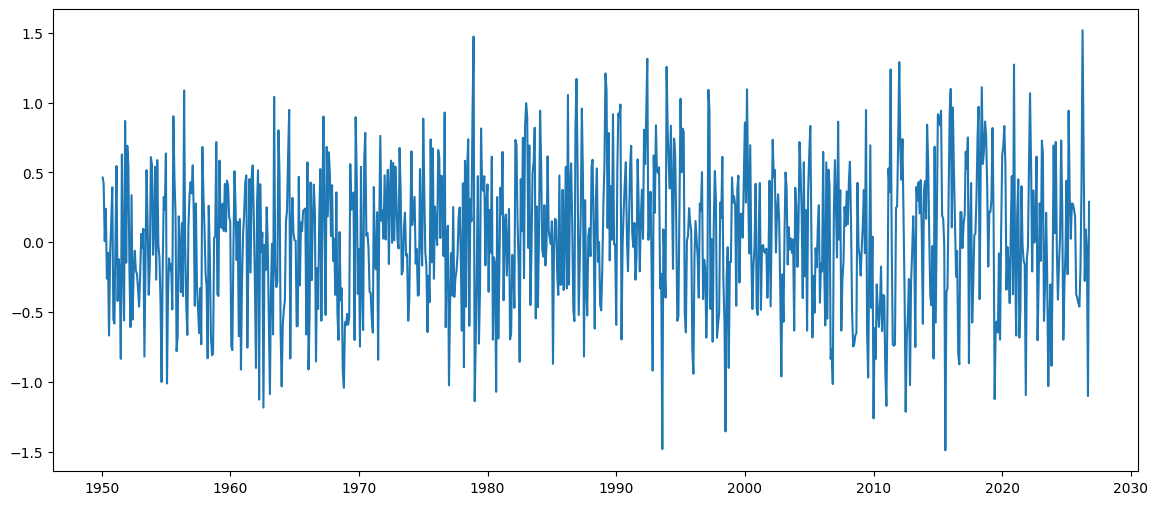

In [13]:
#plot deret waktu
plt.figure(figsize=(14,6))
plt.plot(naos); plt.show()

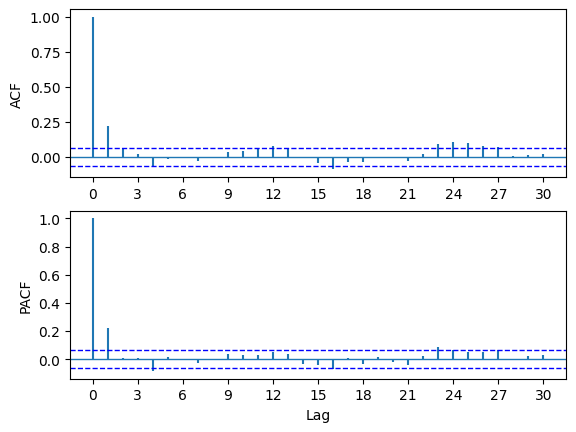

In [14]:
#plot acf dan pacf contoh
acf_pacf_fig(naos, both=True, lag=30); plt.show()

In [15]:
from statsmodels.tsa.stattools import adfuller
adfuller(naos, autolag='AIC')[1]

5.736602293407895e-28

Proses eksplorasi deret secara detail sudah dibahas pada perkuliahan minggu ke-4. Berdasarkan plot ACF dan PACF contoh tampak bahwa lag yang signifikan adalah lag 1 (baik dari ACF maupun PACF). Sehingga model yang bisa dicobakan adalah model AR (1), atau MA (1). Alat bantu identifikasi model yang lainnya adalah EACF.

In [16]:
!pip install rpy2

In [17]:
import warnings
warnings.filterwarnings("ignore")

#Jalankan syntax ini cukup satu kali, jangan berulang
%load_ext rpy2.ipython

In [18]:
%%R
install.packages('TSA')
library (TSA)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
also installing the dependencies ‘xts’, ‘TTR’, ‘quadprog’, ‘zoo’, ‘quantmod’, ‘leaps’, ‘locfit’, ‘tseries’

trying URL 'https://cran.rstudio.com/src/contrib/xts_0.14.3.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/TTR_0.24.4.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/quadprog_1.5-8.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/zoo_1.9-0.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/quantmod_0.4.29.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/leaps_3.2.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/locfit_1.5-9.12.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/tseries_0.10-63.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/TSA_1.3.1.tar.gz'

The downloaded source packages are in
	‘/tmp/RtmpM5mLaN/downloaded_packages’

Attaching package: ‘TSA’

The following objects are masked from ‘package:stats’:

    acf, arima

The f

In [19]:
%%R -i naos
#membuat plot EACF dari data naos
eacf(as.numeric(naos))

AR/MA
  0 1 2 3 4 5 6 7 8 9 10 11 12 13
0 x o o x o o o o o o o  x  o  o 
1 o o o x o o o o o o o  o  x  o 
2 x o x x o o o o o o o  o  o  o 
3 x x x x o o o o o o o  o  o  o 
4 x o x o o o o o o o o  o  o  o 
5 x o x x x x o o o o o  o  o  o 
6 x x o o x o o o o o o  o  o  o 
7 o x o o x x o o o o o  o  o  o 


Penentuan ordo model berdasarkan plot EACF dilakukan dengan melihat pola segitiga tanda `o`. Dari plot EACF yang didapat, terlihat segitiga yang terbentuk berada pada ordo `p=0, q=1` atau `p=1, q=0` atau `p=1, q=1`. Ordo tentatif lain seperti `p=0, q=2`, `p=1, q=2`, `p=2, q=1` juga dapat digunakan.

In [20]:
#model MA (1)
model_ma1=ARIMA(naos,order=(0,0,1)).fit()

In [21]:
print(model_ma1.summary())

                               SARIMAX Results                                
Dep. Variable:         nao_index_cdas   No. Observations:                  921
Model:                 ARIMA(0, 0, 1)   Log Likelihood                -667.567
Date:                Wed, 23 Sep 2026   AIC                           1341.134
Time:                        01:05:48   BIC                           1355.611
Sample:                    01-31-1950   HQIC                          1346.658
                         - 09-30-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0278      0.020      1.386      0.166      -0.011       0.067
ma.L1          0.2133      0.033      6.555      0.000       0.150       0.277
sigma2         0.2495      0.013     19.771      0.0

Perhatikan hasil fitting model MA (1) di atas. Penduga parameter untuk komponen MA yaitu $(\theta_1)$ signifikan.

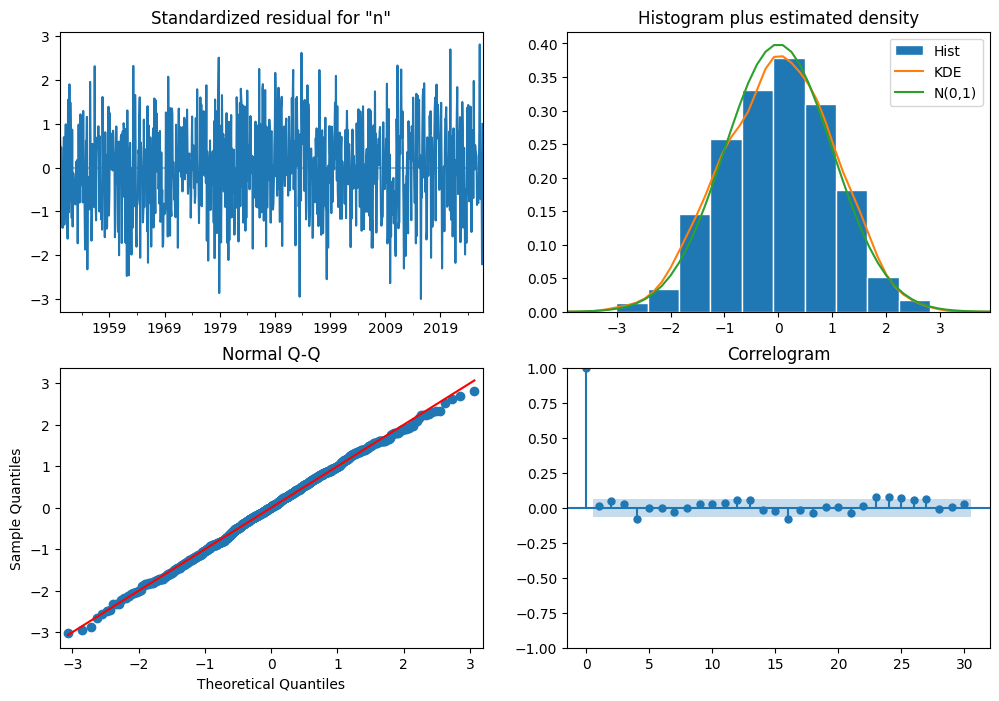

In [22]:
#Analisis Sisaan Model
model_ma1.plot_diagnostics(figsize=(12,8), lags=30)
plt.show()

In [23]:
model_ma1.test_heteroskedasticity('breakvar')

array([[1.17473352, 0.15885655]])

In [24]:
from statsmodels.stats.diagnostic import het_arch
het_arch(model_ma1.resid, nlags=30)[1]

np.float64(0.7075739570085975)

In [25]:
from statsmodels.sandbox.stats.runs import runstest_1samp
runstest_1samp(model_ma1.resid, correction=False)

(np.float64(-0.6895162632689241), np.float64(0.4904984423946366))

In [26]:
from scipy.stats import shapiro
stat,p = shapiro(model_ma1.resid)
print(stat,p)

0.9975654881166186 0.19122789991733924


In [27]:
from scipy.stats import jarque_bera

jb_stat, jb_pval = jarque_bera(model_ma1.resid)
print(jb_stat, jb_pval)

4.470042878863891 0.106989836027217


Apakah model MA (1) sudah memenuhi asumsi model?

Model lain yang dicobakan adalah AR (1)

In [28]:
#model AR (1)
model_ar1=ARIMA(naos,order=(1,0,0)).fit()

In [29]:
print(model_ar1.summary())

                               SARIMAX Results                                
Dep. Variable:         nao_index_cdas   No. Observations:                  921
Model:                 ARIMA(1, 0, 0)   Log Likelihood                -666.328
Date:                Wed, 23 Sep 2026   AIC                           1338.656
Time:                        01:05:49   BIC                           1353.132
Sample:                    01-31-1950   HQIC                          1344.180
                         - 09-30-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0278      0.021      1.309      0.190      -0.014       0.069
ar.L1          0.2225      0.032      6.993      0.000       0.160       0.285
sigma2         0.2488      0.013     19.770      0.0

Hasil fitting model AR (1) menunjukkan penduga parameter untuk komponen AR yaitu $(\phi_1)$ signifikan.

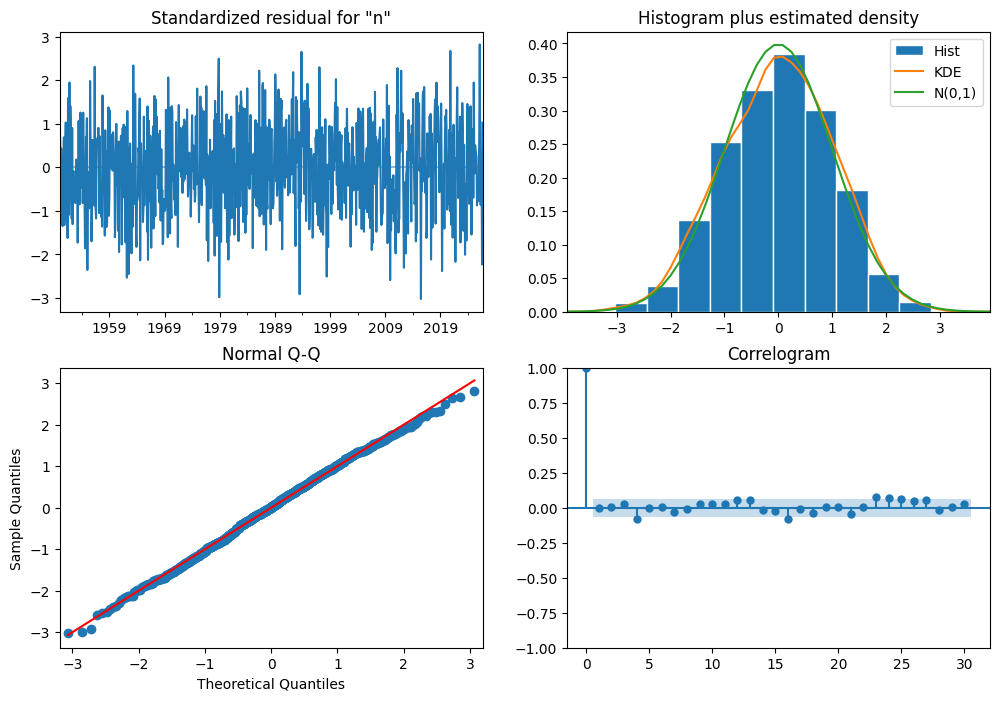

In [30]:
#Analisis Sisaan Model
model_ar1.plot_diagnostics(figsize=(12,8), lags=30)
plt.show()

In [31]:
model_ar1.test_heteroskedasticity('breakvar')

array([[1.15925178, 0.19602124]])

In [32]:
from statsmodels.stats.diagnostic import het_arch
het_arch(model_ar1.resid, nlags=30)[1]

np.float64(0.7318397207000953)

In [33]:
from statsmodels.sandbox.stats.runs import runstest_1samp
runstest_1samp(model_ar1.resid, correction=False)

(np.float64(-0.6906357918303673), np.float64(0.48979444890637025))

In [34]:
from scipy.stats import shapiro
stat,p = shapiro(model_ar1.resid)
print(stat,p)

0.9975637331277335 0.19074373138879314


In [35]:
from scipy.stats import jarque_bera

jb_stat, jb_pval = jarque_bera(model_ar1.resid)
print(jb_stat, jb_pval)

4.6665013202528876 0.09697998517937081


Apakah model AR (1) sudah memenuhi asumsi model?

Selanjutnya ditentukan model terbaik antara model MA (1) dan AR (1). Pemilihan model terbaik bisa berdasarkan beberapa kriteria, misalnya nilai AIC dan BIC model.

In [36]:
pd.DataFrame({'Model':['MA(1)','AR(1)'],
            'AIC':[model_ma1.aic,model_ar1.aic],
            'BIC':[model_ma1.bic,model_ar1.bic]})

,Model,AIC,BIC
0,MA(1),1341.134420,1355.610800
1,AR(1),1338.656093,1353.132473


Berdasarkan nilai AIC dan BIC model yang lebih baik adalah model AR (1). Selanjutnya dilakukan overfitting model dengan mencobakan model AR (2).

In [37]:
#model AR (2)
model_ar2=ARIMA(naos,order=(2,0,0)).fit()

In [38]:
print(model_ar2.summary())

                               SARIMAX Results                                
Dep. Variable:         nao_index_cdas   No. Observations:                  921
Model:                 ARIMA(2, 0, 0)   Log Likelihood                -666.286
Date:                Wed, 23 Sep 2026   AIC                           1340.572
Time:                        01:05:50   BIC                           1359.873
Sample:                    01-31-1950   HQIC                          1347.937
                         - 09-30-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0278      0.021      1.295      0.195      -0.014       0.070
ar.L1          0.2204      0.033      6.663      0.000       0.156       0.285
ar.L2          0.0096      0.035      0.278      0.7

In [39]:
#model ARMA (1,1)
model_arma11=ARIMA(naos,order=(1,0,1)).fit()

In [40]:
print(model_arma11.summary())

                               SARIMAX Results                                
Dep. Variable:         nao_index_cdas   No. Observations:                  921
Model:                 ARIMA(1, 0, 1)   Log Likelihood                -666.285
Date:                Wed, 23 Sep 2026   AIC                           1340.569
Time:                        01:05:51   BIC                           1359.871
Sample:                    01-31-1950   HQIC                          1347.935
                         - 09-30-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0278      0.021      1.294      0.196      -0.014       0.070
ar.L1          0.2654      0.148      1.791      0.073      -0.025       0.556
ma.L1         -0.0451      0.155     -0.291      0.7

Hasil fitting model AR (2) maupun model ARMA (1,1) memberikan hasil bahwa penduga parameter untuk komponen AR yaitu $(\phi_2)$ dan komponen MA yaitu $(\theta_1)$ tidak signifikan, sehingga model AR (2) atau ARMA (1,1) tidak lebih baik daripada model AR (1).

In [41]:
prediksi=model_ar1.get_forecast(12).summary_frame(alpha=0.05)

In [42]:
prediksi

nao_index_cdas,mean,mean_se,mean_ci_lower,mean_ci_upper
2026-10-31,0.086049,0.498829,-0.891637,1.063735
2026-11-30,0.040750,0.511029,-0.960849,1.042349
2026-12-31,0.030670,0.511626,-0.972098,1.033438
2027-01-31,0.028427,0.511655,-0.974399,1.031253
2027-02-28,0.027928,0.511657,-0.974901,1.030757
2027-03-31,0.027817,0.511657,-0.975012,1.030646
2027-04-30,0.027792,0.511657,-0.975037,1.030621
2027-05-31,0.027787,0.511657,-0.975042,1.030615
2027-06-30,0.027785,0.511657,-0.975043,1.030614
2027-07-31,0.027785,0.511657,-0.975044,1.030614


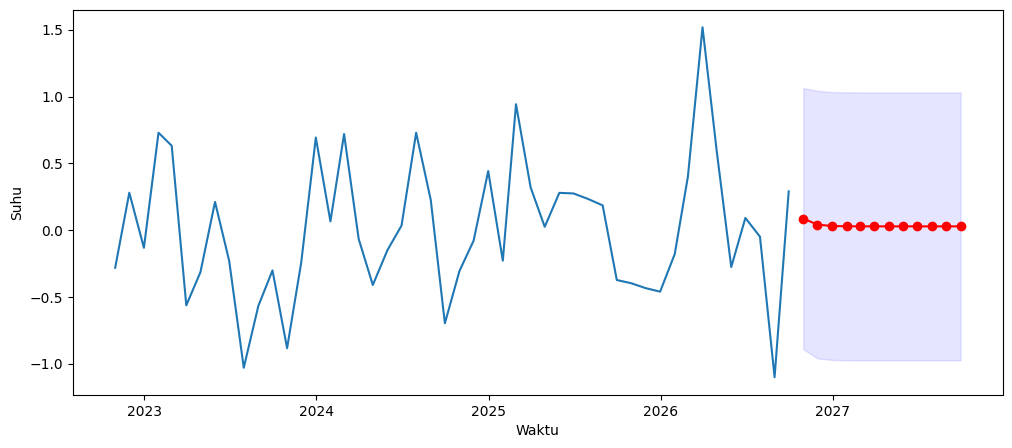

In [43]:
plt.figure(figsize=(12,5))
plt.plot(naos[-48:])
plt.plot(prediksi['mean'],'-or')
plt.fill_between(prediksi.index,prediksi['mean_ci_lower'], prediksi['mean_ci_upper'], color='b', alpha=.1)
plt.xlabel('Waktu'), plt.ylabel('Suhu')
plt.show()

<h2> Pemodelan dengan Pembagian Data Training dan Testing </h2>

In [44]:
#pembagian data training testing
size_train=round(0.9*naos.shape[0])
train, test=naos[:size_train], naos[size_train:]

In [45]:
train

,nao_index_cdas
1950-01-31,0.463516
1950-02-28,0.420714
1950-03-31,0.008387
1950-04-30,0.239433
1950-05-31,-0.261226
...,...
2018-09-30,0.768065
2018-10-31,0.404114
2018-11-30,-0.174024
2018-12-31,0.220080


In [46]:
test

,nao_index_cdas
2019-02-28,0.299153
2019-03-31,0.818603
2019-04-30,0.193447
2019-05-31,-1.123443
2019-06-30,-0.586957
...,...
2026-05-31,-0.276665
2026-06-30,0.091036
2026-07-31,-0.049862
2026-08-31,-1.101628


In [47]:
adfuller(train, autolag='AIC')[1]

0.0

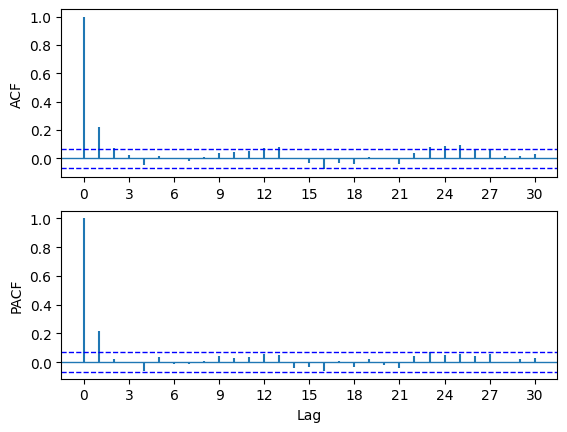

In [48]:
acf_pacf_fig(train, both=True, lag=30); plt.show()

In [49]:
#model MA (1)
train_ma1=ARIMA(train,order=(0,0,1)).fit()

In [50]:
print(train_ma1.summary())

                               SARIMAX Results                                
Dep. Variable:         nao_index_cdas   No. Observations:                  829
Model:                 ARIMA(0, 0, 1)   Log Likelihood                -597.977
Date:                Wed, 23 Sep 2026   AIC                           1201.954
Time:                        01:05:52   BIC                           1216.114
Sample:                    01-31-1950   HQIC                          1207.384
                         - 01-31-2019                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0298      0.021      1.424      0.154      -0.011       0.071
ma.L1          0.2032      0.034      6.028      0.000       0.137       0.269
sigma2         0.2478      0.013     18.466      0.0

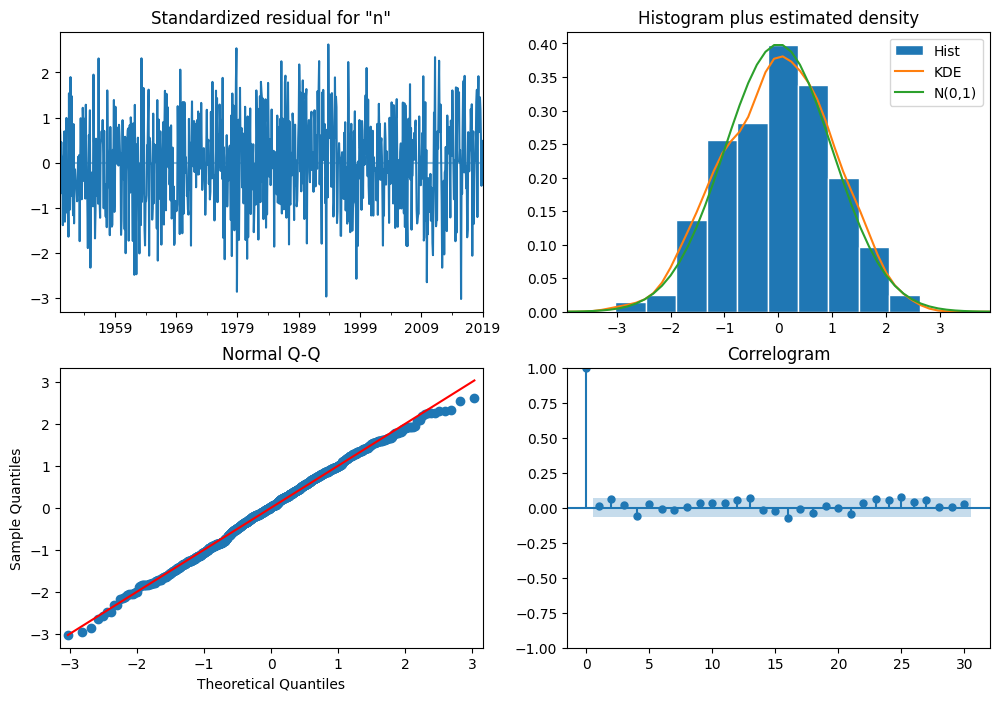

In [51]:
train_ma1.plot_diagnostics(figsize=(12,8), lags=30); plt.show()

In [52]:
het_arch(train_ma1.resid, nlags=30)[1]

np.float64(0.4843092191462428)

In [53]:
runstest_1samp(train_ma1.resid, correction=False)

(np.float64(-0.9987155709453669), np.float64(0.3179324955138281))

In [54]:
stat,p = shapiro(train_ma1.resid)
print(stat,p)

0.9962719526252026 0.04633899074145802


In [55]:
train_ar1=ARIMA(train,order=(1,0,0)).fit()

In [56]:
print(train_ar1.summary())

                               SARIMAX Results                                
Dep. Variable:         nao_index_cdas   No. Observations:                  829
Model:                 ARIMA(1, 0, 0)   Log Likelihood                -596.327
Date:                Wed, 23 Sep 2026   AIC                           1198.655
Time:                        01:05:53   BIC                           1212.816
Sample:                    01-31-1950   HQIC                          1204.086
                         - 01-31-2019                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0299      0.022      1.345      0.179      -0.014       0.073
ar.L1          0.2190      0.033      6.692      0.000       0.155       0.283
sigma2         0.2468      0.013     18.477      0.0

In [57]:
het_arch(train_ar1.resid, nlags=30)[1]

np.float64(0.5001384014614871)

In [58]:
runstest_1samp(train_ar1.resid, correction=False)

(np.float64(-0.8655172345940554), np.float64(0.3867549606399058))

In [59]:
stat,p = shapiro(train_ar1.resid)
print(stat,p)

0.9964149547934484 0.056446284096378384


In [60]:
pd.DataFrame({'Model':['MA(1)','AR(1)'],
            'AIC':[train_ma1.aic,train_ar1.aic],
            'BIC':[train_ma1.bic,train_ar1.bic]})

,Model,AIC,BIC
0,MA(1),1201.953676,1216.114337
1,AR(1),1198.654863,1212.815524


In [61]:
prediksi_test=train_ar1.get_forecast(test.shape[0]).summary_frame(alpha=0.05)

In [62]:
prediksi_test

nao_index_cdas,mean,mean_se,mean_ci_lower,mean_ci_upper
2019-02-28,0.070908,0.496762,-0.902728,1.044543
2019-03-31,0.038858,0.508536,-0.957854,1.035570
2019-04-30,0.031839,0.509094,-0.965967,1.029644
2019-05-31,0.030302,0.509121,-0.967556,1.028160
2019-06-30,0.029965,0.509122,-0.967895,1.027825
...,...,...,...,...
2026-05-31,0.029871,0.509122,-0.967990,1.027731
2026-06-30,0.029871,0.509122,-0.967990,1.027731
2026-07-31,0.029871,0.509122,-0.967990,1.027731
2026-08-31,0.029871,0.509122,-0.967990,1.027731


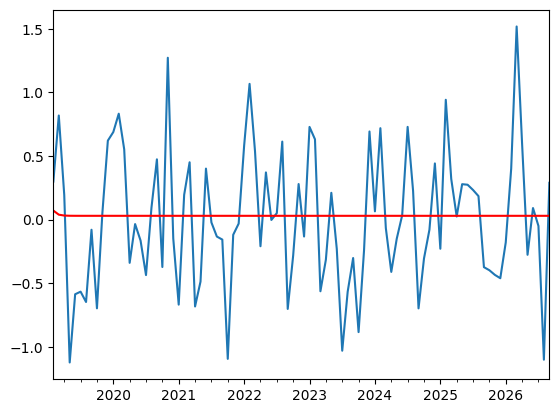

In [63]:
test.plot()
prediksi_test['mean'].plot(color='red')
plt.show()

In [64]:
from sklearn.metrics import mean_absolute_percentage_error,mean_squared_error,mean_absolute_error
print('MAPE: ',mean_absolute_percentage_error(test,prediksi_test['mean'])*100, '%')
print('MSE: ',mean_squared_error(test,prediksi_test['mean']))
print('MAE: ',mean_absolute_error(test,prediksi_test['mean']))

MAPE:  114.22759505598063 %
MSE:  0.2847831022445176
MAE:  0.4293052975746584


Perhatikan bahwa nilai MAPE yang sangat besar. Berdasarkan plot perbandingan antara data test dan hasil prediksi tampak pola hasil prediksi hampir konstan sementara nilai data test sangat fluktiatif, yang berarti bahwa nilai hasil prediksi sangat jauh dari data test. Sedangkan nilai MSE dan MAE sangat kecil. Nilai MSE dan MAE akan relatif terhadap satuan data yang digunakan. Karena data naos dalam skala $10^{-1}$ sehingga nilai MSE dan MAE akan mengikuti skala tersebut.

##TUGAS KELOMPOK

Lakukan simulasi deret stasioner. Gunakan seed jumlah 2 digit terakhir semua anggota kelompok = 120.

1. Simulasikan deret MA (1) deret parameter $\theta=0.6$ dan panjang amatan 120.

2. Lakukan pembagian data latih dan data uji terhadap deret hasil simulasi (proporsi pembagian data bebas, sesuaikan dengan pola deret).

3. Buatlah plot ACF, PACF, dan EACF dari data latih. Identifikasi model yang tepat untuk deret simulasi berdasarkan plot-plot tersebut, kemudian lakukan pengepasan model terhadap data latij.

4. Lakukan pengecekan diagnostik sisaan model, overfitting, dan tentukan model terbaik berdasarkan kriteria AIC dan BIC.

5. Gunakan model terbaik untuk melakukan peramalan sepanjang periode data uji. Hitunglah metrik evaluasi MAPE dan RMSE dari hasil peramalan dan data latih maupun data uji. Interpretasikan apakah model yang digunakan sudah baik.

6. Lakukan tahapan 2-5 dengan deret simulasi yang berbeda, yaitu deret AR(2) dengan $n=100$ dan parameter $\phi_1=0.9$ dan $\phi_2=-0.5$; deret ARMA(1,1) dengan $n=200$ dan parameter $\phi=0.4$ dan $\theta=0.6$.

Pengumpulan hasil diskusi:

- melalui class.ipb.ac.id cukup perwakilan kelompok dengan format pdf. Dalam file tersebut memuat identitas anggota kelompok (Nama, NIM). Dalam file tidak perlu mencantumkan sintaks, namun menampilkan plot deret waktu dari deret simulasi dan interpretasinya; pembagian data latih data uji dan alasan pemilihan pembagian data; plot ACF, PACF, EACF, dan interpretasinya; hasil pengepasan model dan diagnostik sisaan model dan interpretasinya; plot hasil peramalan dan deret asli, nilai metrik evaluasi, dan interpretasinya.

- melalui github masing-masing anggota kelompok berupa file sintaks.

Simulated MA(1) Series Head:
1950-01-31    0.147450
1950-02-28    2.113310
1950-03-31    0.788024
1950-04-30    2.054162
1950-05-31    2.014834
Freq: ME, Name: simulated_ma1, dtype: float64

Simulated MA(1) Series Tail:
1959-08-31   -1.536144
1959-09-30   -0.744072
1959-10-31    0.315023
1959-11-30    0.012006
1959-12-31    0.323000
Freq: ME, Name: simulated_ma1, dtype: float64


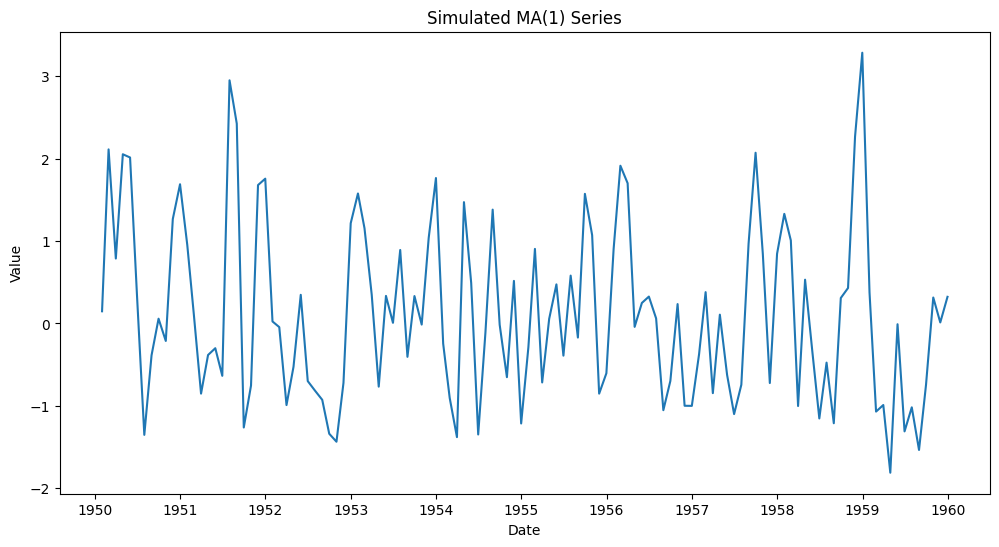


Training data size for MA(1): 96
Testing data size for MA(1): 24

ACF and PACF plots for MA(1) training data:


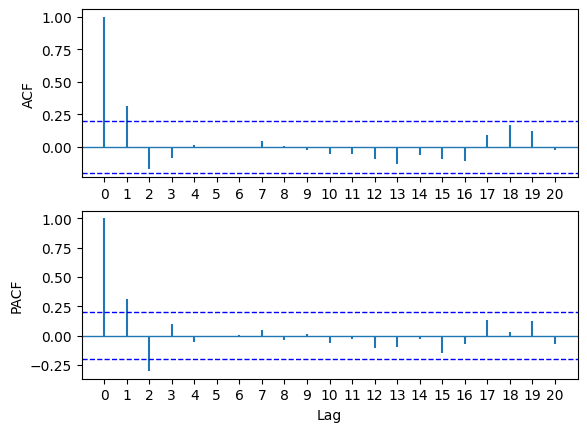


EACF for MA(1) training data:
AR/MA
  0 1 2 3 4 5 6 7 8 9 10 11 12 13
0 x o o o o o o o o o o  o  o  o 
1 x x o o o o o o o o o  o  o  o 
2 x o o o o o o o o o o  o  o  o 
3 x o o o o o o o o o o  o  o  o 
4 o o o o o o o o o o o  o  o  o 
5 o o o o o o o o o o o  o  o  o 
6 o x o o o o o o o o o  o  o  o 
7 x o x o o o o o o o o  o  o  o 

Fitting MA(1) model:
                               SARIMAX Results                                
Dep. Variable:          simulated_ma1   No. Observations:                   96
Model:                 ARIMA(0, 0, 1)   Log Likelihood                -129.365
Date:                Wed, 23 Sep 2026   AIC                            264.729
Time:                        01:18:43   BIC                            272.422
Sample:                    01-31-1950   HQIC                           267.839
                         - 12-31-1957                                         
Covariance Type:                  opg                                         
   

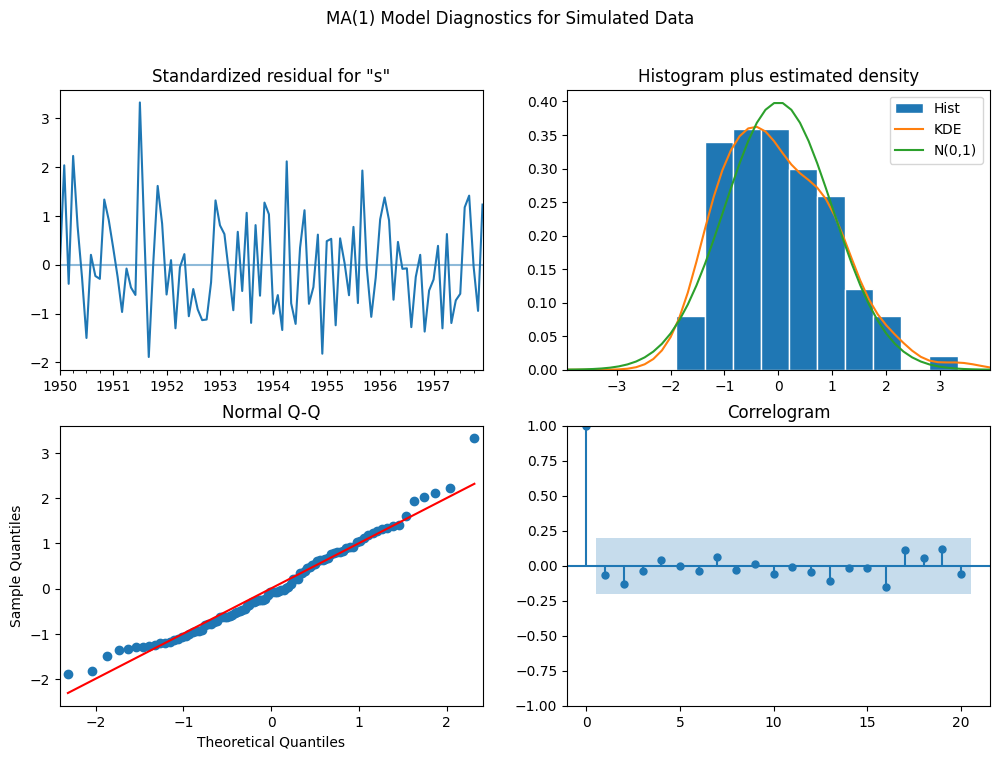


Fitting AR(1) model:
                               SARIMAX Results                                
Dep. Variable:          simulated_ma1   No. Observations:                   96
Model:                 ARIMA(1, 0, 0)   Log Likelihood                -133.722
Date:                Wed, 23 Sep 2026   AIC                            273.444
Time:                        01:18:45   BIC                            281.138
Sample:                    01-31-1950   HQIC                           276.554
                         - 12-31-1957                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1756      0.156      1.124      0.261      -0.130       0.482
ar.L1          0.3089      0.101      3.058      0.002       0.111       0.507
sigma2         0.9483      0.1

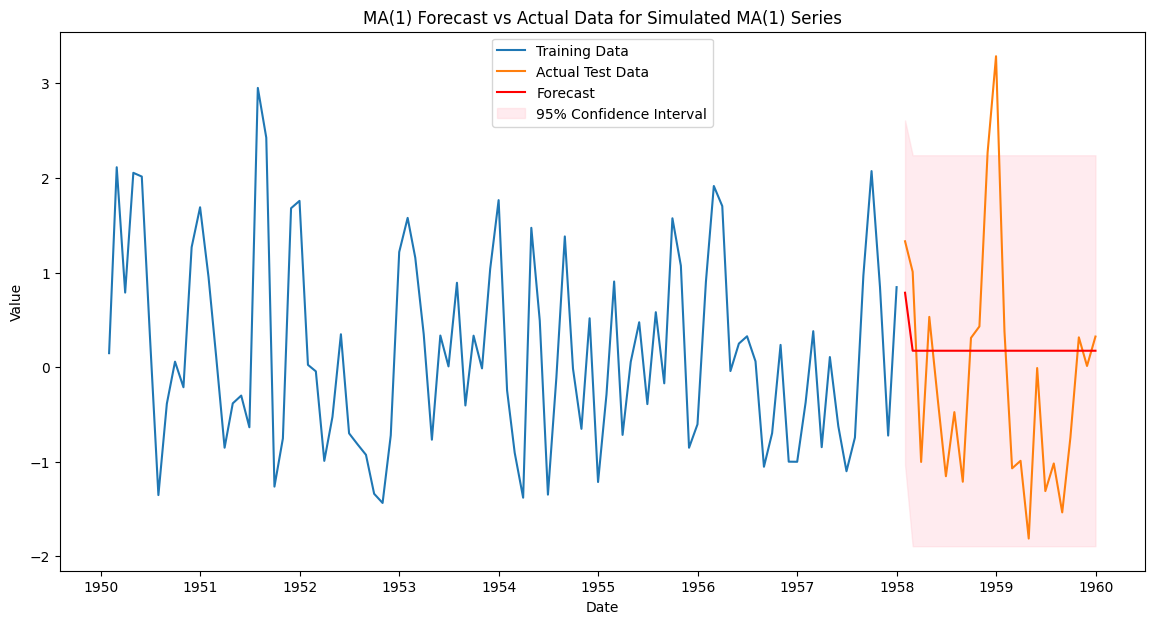


Evaluation Metrics for MA(1) Forecast on simulated MA(1) series:
MAPE: 220.27%
RMSE: 1.2146
MAE: 0.9550


--- Starting Simulation and Analysis for AR(2) Series ---

Simulated AR(2) Series Head:
1950-01-31    1.815434
1950-02-28    0.753345
1950-03-31    0.701814
1950-04-30    0.606474
1950-05-31   -0.682511
Freq: ME, Name: simulated_ar2, dtype: float64

Simulated AR(2) Series Tail:
1957-12-31   -2.205677
1958-01-31   -0.605263
1958-02-28    1.659481
1958-03-31    0.671785
1958-04-30    0.746314
Freq: ME, Name: simulated_ar2, dtype: float64


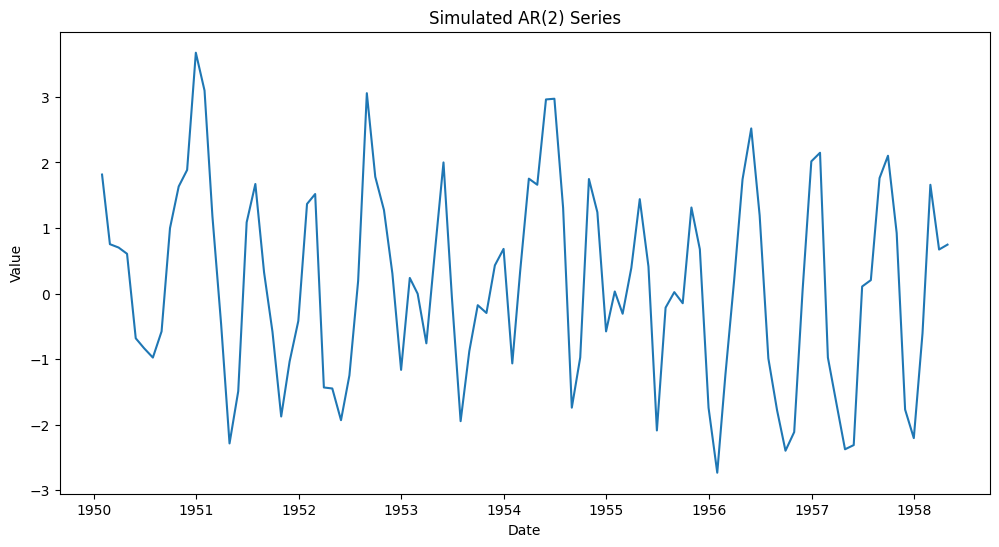


Training data size for AR(2): 80
Testing data size for AR(2): 20

ACF and PACF plots for AR(2) training data:


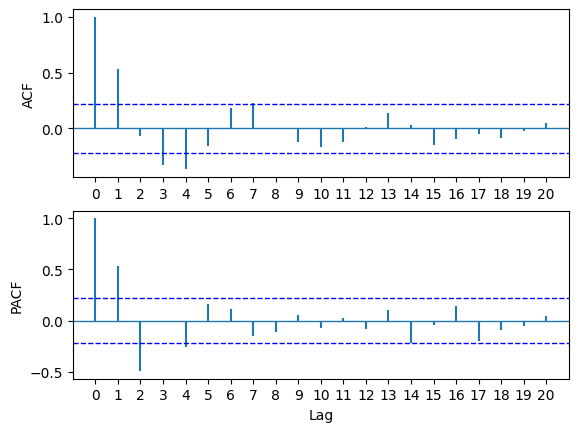


EACF for AR(2) training data:
AR/MA
  0 1 2 3 4 5 6 7 8 9 10 11 12 13
0 x o x x o o o o o o o  o  o  o 
1 x o o x o x x o o o o  o  o  o 
2 o x x o x o o x o o o  o  o  o 
3 o x x o x o o x o o o  o  o  o 
4 x x o o o o o x o o o  o  o  o 
5 x x o o o o o x o o o  o  o  o 
6 x x o o o o o o o o o  o  o  o 
7 x x o o o o o o o o o  o  o  o 

Fitting AR(2) model:
                               SARIMAX Results                                
Dep. Variable:          simulated_ar2   No. Observations:                   80
Model:                 ARIMA(2, 0, 0)   Log Likelihood                -116.161
Date:                Wed, 23 Sep 2026   AIC                            240.321
Time:                        01:18:46   BIC                            249.849
Sample:                    01-31-1950   HQIC                           244.141
                         - 08-31-1956                                         
Covariance Type:                  opg                                         
   

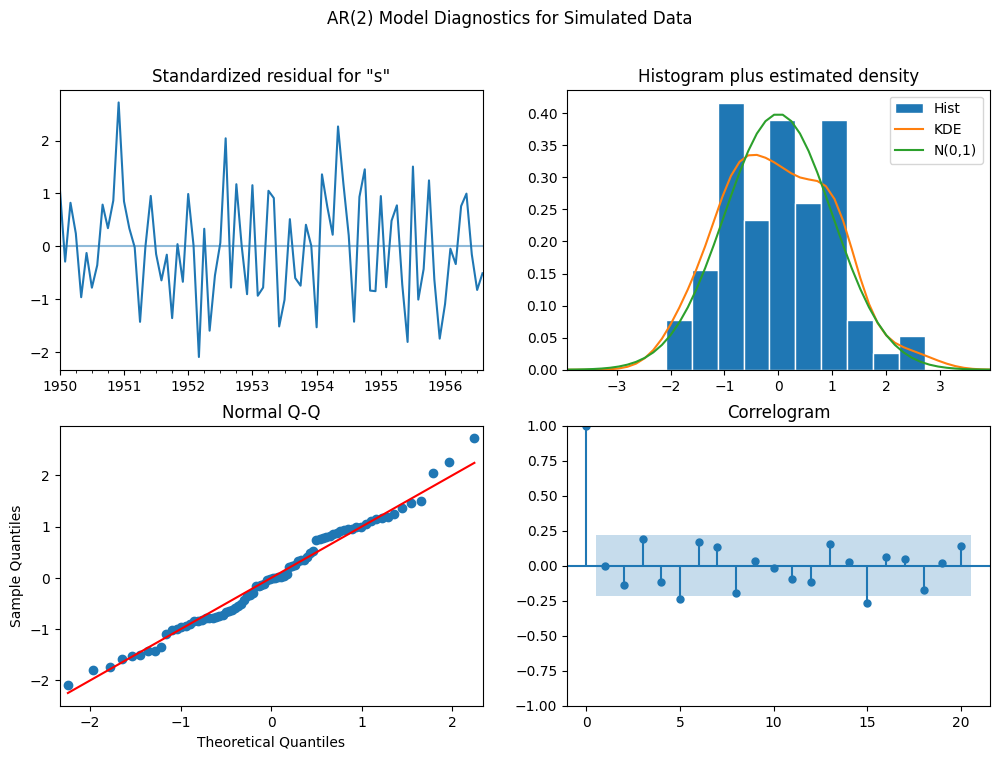


Fitting AR(1) model for comparison:
                               SARIMAX Results                                
Dep. Variable:          simulated_ar2   No. Observations:                   80
Model:                 ARIMA(1, 0, 0)   Log Likelihood                -128.082
Date:                Wed, 23 Sep 2026   AIC                            262.164
Time:                        01:18:47   BIC                            269.310
Sample:                    01-31-1950   HQIC                           265.029
                         - 08-31-1956                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2265      0.295      0.769      0.442      -0.351       0.804
ar.L1          0.5467      0.118      4.644      0.000       0.316       0.777
sigma2         

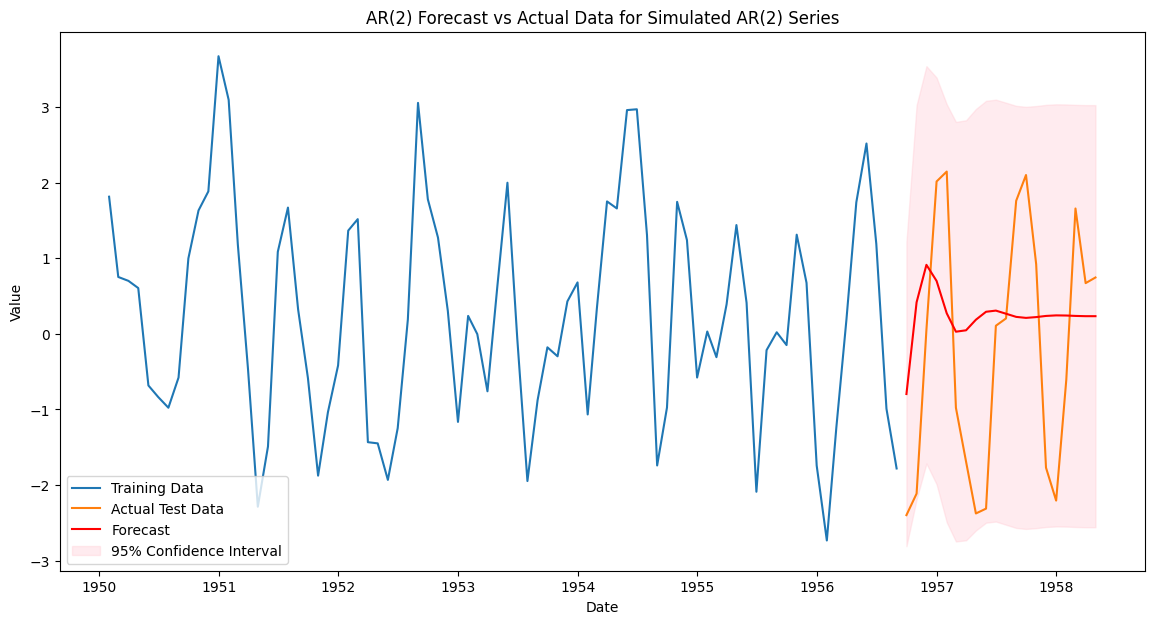


Evaluation Metrics for AR(2) Forecast on simulated AR(2) series:
MAPE: 169.45%
RMSE: 1.6133
MAE: 1.4082


--- Starting Simulation and Analysis for ARMA(1,1) Series ---

Simulated ARMA(1,1) Series Head:
1950-01-31    0.256692
1950-02-28    0.764315
1950-03-31   -0.301168
1950-04-30   -0.871840
1950-05-31    0.990519
Freq: ME, Name: simulated_arma11, dtype: float64

Simulated ARMA(1,1) Series Tail:
1966-04-30   -2.030829
1966-05-31   -0.655719
1966-06-30   -0.081607
1966-07-31    1.246976
1966-08-31    1.378104
Freq: ME, Name: simulated_arma11, dtype: float64


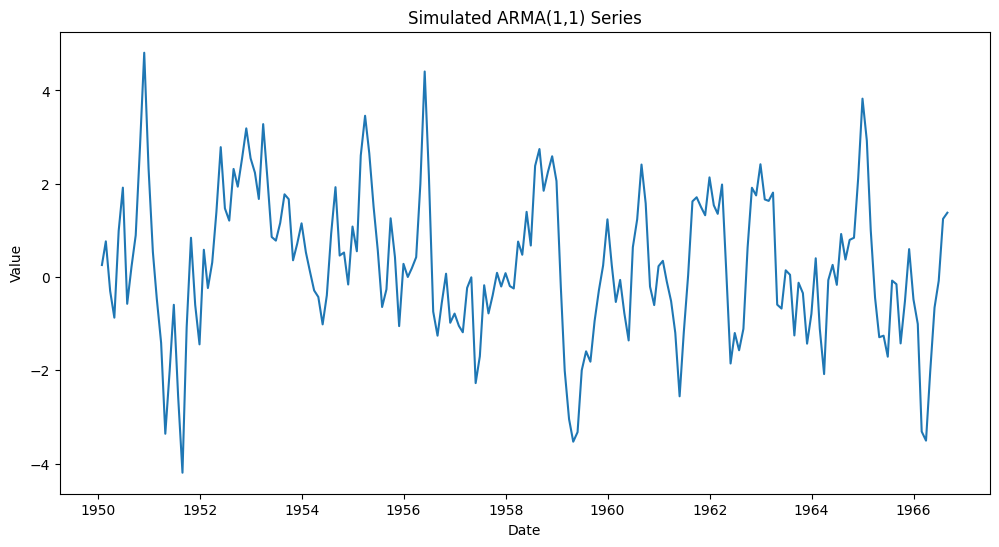


Training data size for ARMA(1,1): 160
Testing data size for ARMA(1,1): 40

ACF and PACF plots for ARMA(1,1) training data:


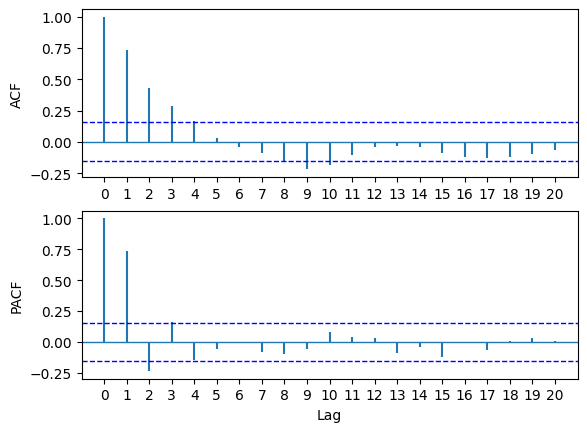


EACF for ARMA(1,1) training data:
AR/MA
  0 1 2 3 4 5 6 7 8 9 10 11 12 13
0 x x x x o o o x x x o  o  o  o 
1 x o o o o o o o x o o  o  o  o 
2 x o o x o o o o o o o  o  o  o 
3 x o x x o o o o o o o  o  o  o 
4 x o x o o o o o o o o  o  o  o 
5 o o x o o o o o o o o  o  o  o 
6 o x x o o x o o o o o  o  o  o 
7 x x o x o o o o o o o  o  o  o 

Fitting ARMA(1,1) model:
                               SARIMAX Results                                
Dep. Variable:       simulated_arma11   No. Observations:                  160
Model:                 ARIMA(1, 0, 1)   Log Likelihood                -228.718
Date:                Wed, 23 Sep 2026   AIC                            465.436
Time:                        01:18:49   BIC                            477.737
Sample:                    01-31-1950   HQIC                           470.431
                         - 04-30-1963                                         
Covariance Type:                  opg                                     

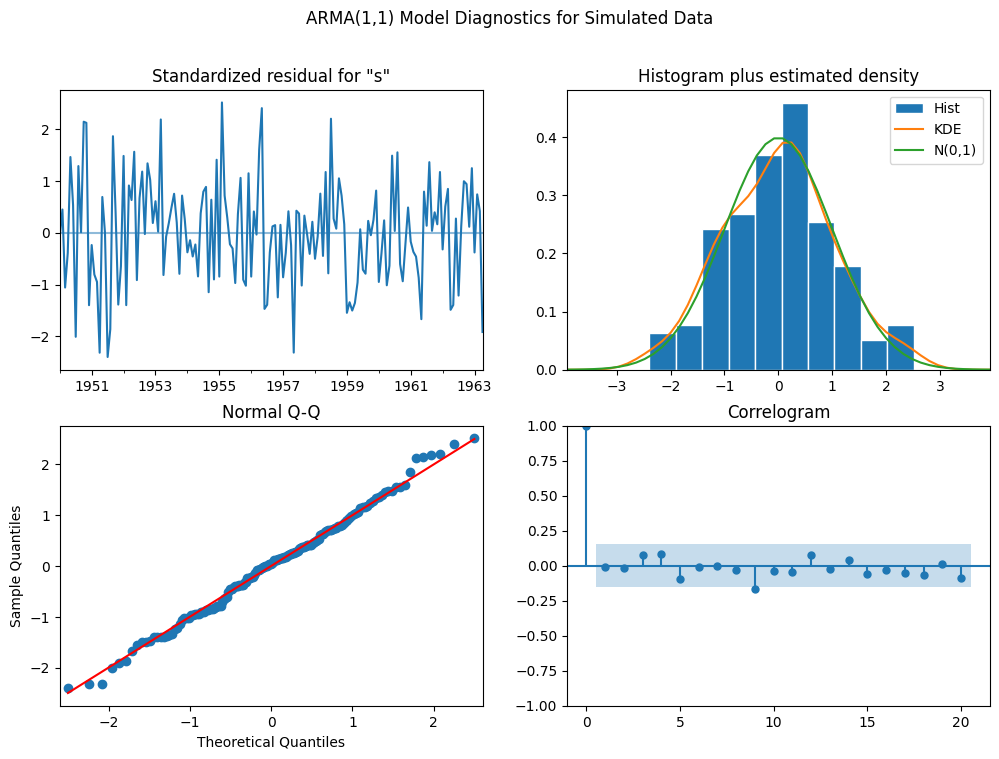


Fitting AR(1) model for comparison:
                               SARIMAX Results                                
Dep. Variable:       simulated_arma11   No. Observations:                  160
Model:                 ARIMA(1, 0, 0)   Log Likelihood                -236.665
Date:                Wed, 23 Sep 2026   AIC                            479.330
Time:                        01:18:50   BIC                            488.556
Sample:                    01-31-1950   HQIC                           483.076
                         - 04-30-1963                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3713      0.313      1.186      0.236      -0.242       0.985
ar.L1          0.7319      0.051     14.417      0.000       0.632       0.831
sigma2         

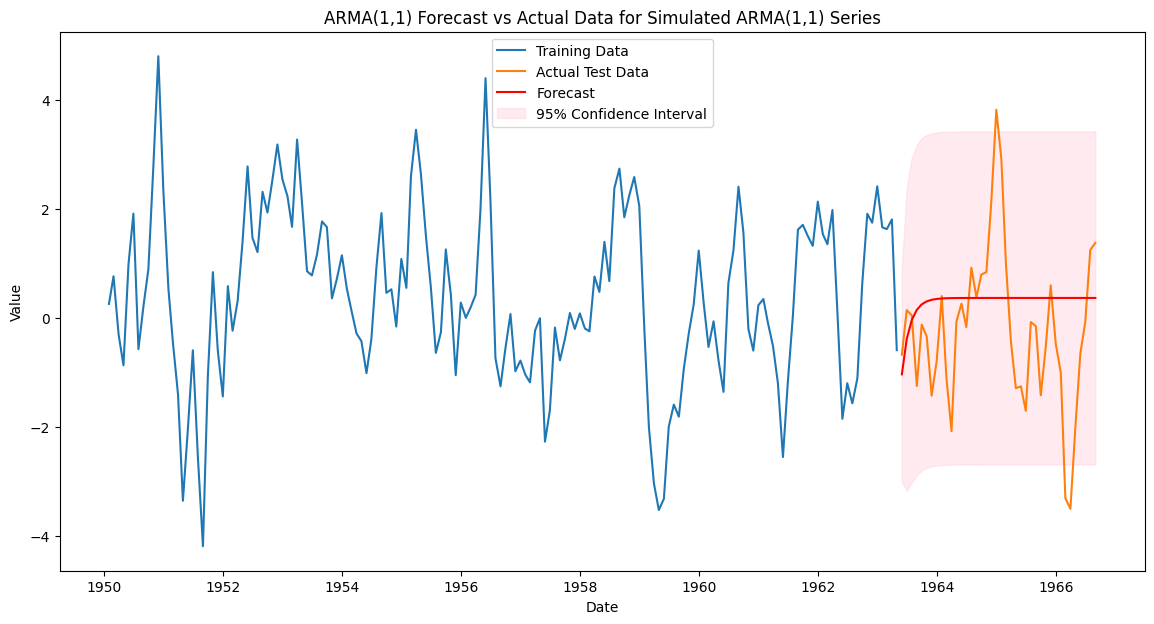


Evaluation Metrics for ARMA(1,1) Forecast on simulated ARMA(1,1) series:
MAPE: 163.67%
RMSE: 1.5288
MAE: 1.1697


In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima_process import arma_generate_sample
from statsmodels.tsa.arima.model import ARIMA
from PythonTsa.plot_acf_pacf import acf_pacf_fig
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, mean_absolute_error

# Set seed as requested
np.random.seed(120)

# 1. Simulate MA(1) series
# MA(1) with theta = 0.6. In arma_generate_sample, ma_params is [1, theta1, theta2, ...] for MA(q)
# and ar_params is [1, -phi1, -phi2, ...] for AR(p)
ar_params_ma1 = np.array([1])
ma_params_ma1 = np.array([1, 0.6]) # theta = 0.6
nobs_ma1 = 120

simulated_ma1 = arma_generate_sample(ar_params_ma1, ma_params_ma1, nobs_ma1, scale=1.0)

# Convert to pandas Series for time series analysis
index_ma1 = pd.date_range(start='1950-01-01', periods=nobs_ma1, freq='M')
simulated_ma1_series = pd.Series(simulated_ma1, index=index_ma1, name='simulated_ma1')

print("Simulated MA(1) Series Head:")
print(simulated_ma1_series.head())
print("\nSimulated MA(1) Series Tail:")
print(simulated_ma1_series.tail())

# Plot the simulated series
plt.figure(figsize=(12, 6))
plt.plot(simulated_ma1_series)
plt.title('Simulated MA(1) Series')
plt.xlabel('Date')
plt.ylabel('Value')
plt.show()

# 2. Split data into training and testing (e.g., 80% train, 20% test)
size_train_ma1 = int(0.8 * nobs_ma1)
train_ma1, test_ma1 = simulated_ma1_series[:size_train_ma1], simulated_ma1_series[size_train_ma1:]

print(f"\nTraining data size for MA(1): {len(train_ma1)}")
print(f"Testing data size for MA(1): {len(test_ma1)}")

# 3. Plot ACF, PACF for training data
print("\nACF and PACF plots for MA(1) training data:")
acf_pacf_fig(train_ma1, both=True, lag=20)
plt.show()

# To get EACF, we need to use rpy2. Ensure rpy2 is loaded and TSA package is installed.
# This block assumes rpy2 is already set up and TSA is installed from previous cells.
# If not, the user would need to uncomment and run the following:
# %load_ext rpy2.ipython
# %%R
# install.packages('TSA')
# library(TSA)

print("\nEACF for MA(1) training data:")
# Pass training data to R for EACF
# Check if rpy2 is loaded before attempting %R magic command
import sys
if 'rpy2.ipython' not in sys.modules:
    print("rpy2 extension not loaded. Please run %load_ext rpy2.ipython first.")
    print("EACF plot skipped.")
else:
    try:
        %R -i train_ma1
        %R eacf(as.numeric(train_ma1))
    except Exception as e:
        print(f"Error generating EACF: {e}")

# 4. Model fitting for MA(1)
# Based on ACF/PACF/EACF, we expect MA(1) to be a good candidate.
# Let's fit MA(1), AR(1), and ARMA(1,1) for comparison.

print("\nFitting MA(1) model:")
model_ma1_sim = ARIMA(train_ma1, order=(0, 0, 1)).fit()
print(model_ma1_sim.summary())
model_ma1_sim.plot_diagnostics(figsize=(12, 8), lags=20)
plt.suptitle('MA(1) Model Diagnostics for Simulated Data')
plt.show()

print("\nFitting AR(1) model:")
model_ar1_sim = ARIMA(train_ma1, order=(1, 0, 0)).fit()
print(model_ar1_sim.summary())

print("\nFitting ARMA(1,1) model:")
model_arma11_sim = ARIMA(train_ma1, order=(1, 0, 1)).fit()
print(model_arma11_sim.summary())

# Compare models using AIC and BIC
comparison_df_ma1 = pd.DataFrame({
    'Model': ['MA(1)', 'AR(1)', 'ARMA(1,1)'],
    'AIC': [model_ma1_sim.aic, model_ar1_sim.aic, model_arma11_sim.aic],
    'BIC': [model_ma1_sim.bic, model_ar1_sim.bic, model_arma11_sim.bic]
})
print("\nModel Comparison (AIC/BIC) for MA(1) simulation:")
print(comparison_df_ma1)

# Identify best model (likely MA(1) as it's the true process)
# Choose the model with the lowest AIC/BIC
best_model_ma1_sim = model_ma1_sim # Assuming MA(1) is chosen based on AIC/BIC and parameter significance
print("\nBest model for simulated MA(1) series (based on AIC/BIC and parameter significance): MA(1)")

# 5. Forecasting and Evaluation for MA(1)
print("\nForecasting with the best model (MA(1)) for simulated MA(1) series:")
forecast_ma1 = best_model_ma1_sim.get_forecast(len(test_ma1))
pred_mean_ma1 = forecast_ma1.predicted_mean
conf_int_ma1 = forecast_ma1.conf_int(alpha=0.05)

plt.figure(figsize=(14, 7))
plt.plot(train_ma1.index, train_ma1, label='Training Data')
plt.plot(test_ma1.index, test_ma1, label='Actual Test Data')
plt.plot(pred_mean_ma1.index, pred_mean_ma1, color='red', label='Forecast')
plt.fill_between(conf_int_ma1.index, conf_int_ma1.iloc[:, 0], conf_int_ma1.iloc[:, 1], color='pink', alpha=0.3, label='95% Confidence Interval')
plt.title('MA(1) Forecast vs Actual Data for Simulated MA(1) Series')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.show()

# Evaluate metrics
mape_ma1 = mean_absolute_percentage_error(test_ma1, pred_mean_ma1) * 100
rmse_ma1 = np.sqrt(mean_squared_error(test_ma1, pred_mean_ma1))
mae_ma1 = mean_absolute_error(test_ma1, pred_mean_ma1)

print(f"\nEvaluation Metrics for MA(1) Forecast on simulated MA(1) series:")
print(f"MAPE: {mape_ma1:.2f}%")
print(f"RMSE: {rmse_ma1:.4f}")
print(f"MAE: {mae_ma1:.4f}")

# Interpretation: For a simulated MA(1) process, an MA(1) model should fit well.
# The parameter should be significant and close to the true value (0.6). AIC/BIC should be lowest for MA(1).
# The diagnostic plots should show residuals close to white noise and normally distributed.
# Forecasting metrics (MAPE, RMSE) will indicate how well the model predicts the test set.
# Since this is a simulated series with known parameters, we expect good performance.


# --- Simulation and Analysis for AR(2) Series ---
print("\n\n--- Starting Simulation and Analysis for AR(2) Series ---")

# 1. Simulate AR(2) series
# AR(2) with phi1 = 0.9, phi2 = -0.5. In arma_generate_sample, ar_params is [1, -phi1, -phi2, ...]
ar_params_ar2 = np.array([1, -0.9, 0.5]) # phi1 = 0.9, phi2 = -0.5
ma_params_ar2 = np.array([1])
nobs_ar2 = 100

simulated_ar2 = arma_generate_sample(ar_params_ar2, ma_params_ar2, nobs_ar2, scale=1.0)

# Convert to pandas Series for time series analysis
index_ar2 = pd.date_range(start='1950-01-01', periods=nobs_ar2, freq='M')
simulated_ar2_series = pd.Series(simulated_ar2, index=index_ar2, name='simulated_ar2')

print("\nSimulated AR(2) Series Head:")
print(simulated_ar2_series.head())
print("\nSimulated AR(2) Series Tail:")
print(simulated_ar2_series.tail())

# Plot the simulated series
plt.figure(figsize=(12, 6))
plt.plot(simulated_ar2_series)
plt.title('Simulated AR(2) Series')
plt.xlabel('Date')
plt.ylabel('Value')
plt.show()

# 2. Split data into training and testing (e.g., 80% train, 20% test)
size_train_ar2 = int(0.8 * nobs_ar2)
train_ar2, test_ar2 = simulated_ar2_series[:size_train_ar2], simulated_ar2_series[size_train_ar2:]

print(f"\nTraining data size for AR(2): {len(train_ar2)}")
print(f"Testing data size for AR(2): {len(test_ar2)}")

# 3. Plot ACF, PACF for training data
print("\nACF and PACF plots for AR(2) training data:")
acf_pacf_fig(train_ar2, both=True, lag=20)
plt.show()

print("\nEACF for AR(2) training data:")
if 'rpy2.ipython' not in sys.modules:
    print("rpy2 extension not loaded. Please run %load_ext rpy2.ipython first.")
    print("EACF plot skipped.")
else:
    try:
        %R -i train_ar2
        %R eacf(as.numeric(train_ar2))
    except Exception as e:
        print(f"Error generating EACF: {e}")

# 4. Model fitting for AR(2)
print("\nFitting AR(2) model:")
model_ar2_sim = ARIMA(train_ar2, order=(2, 0, 0)).fit()
print(model_ar2_sim.summary())
model_ar2_sim.plot_diagnostics(figsize=(12, 8), lags=20)
plt.suptitle('AR(2) Model Diagnostics for Simulated Data')
plt.show()

print("\nFitting AR(1) model for comparison:")
model_ar1_sim_comp = ARIMA(train_ar2, order=(1, 0, 0)).fit()
print(model_ar1_sim_comp.summary())

print("\nFitting ARMA(1,1) model for comparison:")
model_arma11_sim_comp = ARIMA(train_ar2, order=(1, 0, 1)).fit()
print(model_arma11_sim_comp.summary())

# Compare models using AIC and BIC
comparison_df_ar2 = pd.DataFrame({
    'Model': ['AR(2)', 'AR(1)', 'ARMA(1,1)'],
    'AIC': [model_ar2_sim.aic, model_ar1_sim_comp.aic, model_arma11_sim_comp.aic],
    'BIC': [model_ar2_sim.bic, model_ar1_sim_comp.bic, model_arma11_sim_comp.bic]
})
print("\nModel Comparison (AIC/BIC) for AR(2) simulation:")
print(comparison_df_ar2)

# Identify best model
best_model_ar2_sim = model_ar2_sim
print("\nBest model for simulated AR(2) series: AR(2)")

# 5. Forecasting and Evaluation for AR(2)
print("\nForecasting with the best model (AR(2)) for simulated AR(2) series:")
forecast_ar2 = best_model_ar2_sim.get_forecast(len(test_ar2))
pred_mean_ar2 = forecast_ar2.predicted_mean
conf_int_ar2 = forecast_ar2.conf_int(alpha=0.05)

plt.figure(figsize=(14, 7))
plt.plot(train_ar2.index, train_ar2, label='Training Data')
plt.plot(test_ar2.index, test_ar2, label='Actual Test Data')
plt.plot(pred_mean_ar2.index, pred_mean_ar2, color='red', label='Forecast')
plt.fill_between(conf_int_ar2.index, conf_int_ar2.iloc[:, 0], conf_int_ar2.iloc[:, 1], color='pink', alpha=0.3, label='95% Confidence Interval')
plt.title('AR(2) Forecast vs Actual Data for Simulated AR(2) Series')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.show()

# Evaluate metrics
mape_ar2 = mean_absolute_percentage_error(test_ar2, pred_mean_ar2) * 100
rmse_ar2 = np.sqrt(mean_squared_error(test_ar2, pred_mean_ar2))
mae_ar2 = mean_absolute_error(test_ar2, pred_mean_ar2)

print(f"\nEvaluation Metrics for AR(2) Forecast on simulated AR(2) series:")
print(f"MAPE: {mape_ar2:.2f}%")
print(f"RMSE: {rmse_ar2:.4f}")
print(f"MAE: {mae_ar2:.4f}")


# --- Simulation and Analysis for ARMA(1,1) Series ---
print("\n\n--- Starting Simulation and Analysis for ARMA(1,1) Series ---")

# 1. Simulate ARMA(1,1) series
# phi = 0.4, theta = 0.6
ar_params_arma11 = np.array([1, -0.4]) # phi = 0.4
ma_params_arma11 = np.array([1, 0.6]) # theta = 0.6
nobs_arma11 = 200

simulated_arma11 = arma_generate_sample(ar_params_arma11, ma_params_arma11, nobs_arma11, scale=1.0)

# Convert to pandas Series for time series analysis
index_arma11 = pd.date_range(start='1950-01-01', periods=nobs_arma11, freq='M')
simulated_arma11_series = pd.Series(simulated_arma11, index=index_arma11, name='simulated_arma11')

print("\nSimulated ARMA(1,1) Series Head:")
print(simulated_arma11_series.head())
print("\nSimulated ARMA(1,1) Series Tail:")
print(simulated_arma11_series.tail())

# Plot the simulated series
plt.figure(figsize=(12, 6))
plt.plot(simulated_arma11_series)
plt.title('Simulated ARMA(1,1) Series')
plt.xlabel('Date')
plt.ylabel('Value')
plt.show()

# 2. Split data into training and testing (e.g., 80% train, 20% test)
size_train_arma11 = int(0.8 * nobs_arma11)
train_arma11, test_arma11 = simulated_arma11_series[:size_train_arma11], simulated_arma11_series[size_train_arma11:]

print(f"\nTraining data size for ARMA(1,1): {len(train_arma11)}")
print(f"Testing data size for ARMA(1,1): {len(test_arma11)}")

# 3. Plot ACF, PACF for training data
print("\nACF and PACF plots for ARMA(1,1) training data:")
acf_pacf_fig(train_arma11, both=True, lag=20)
plt.show()

print("\nEACF for ARMA(1,1) training data:")
if 'rpy2.ipython' not in sys.modules:
    print("rpy2 extension not loaded. Please run %load_ext rpy2.ipython first.")
    print("EACF plot skipped.")
else:
    try:
        %R -i train_arma11
        %R eacf(as.numeric(train_arma11))
    except Exception as e:
        print(f"Error generating EACF: {e}")

# 4. Model fitting for ARMA(1,1)
print("\nFitting ARMA(1,1) model:")
model_arma11_sim = ARIMA(train_arma11, order=(1, 0, 1)).fit()
print(model_arma11_sim.summary())
model_arma11_sim.plot_diagnostics(figsize=(12, 8), lags=20)
plt.suptitle('ARMA(1,1) Model Diagnostics for Simulated Data')
plt.show()

print("\nFitting AR(1) model for comparison:")
model_ar1_sim_arma_comp = ARIMA(train_arma11, order=(1, 0, 0)).fit()
print(model_ar1_sim_arma_comp.summary())

print("\nFitting MA(1) model for comparison:")
model_ma1_sim_arma_comp = ARIMA(train_arma11, order=(0, 0, 1)).fit()
print(model_ma1_sim_arma_comp.summary())

# Compare models using AIC and BIC
comparison_df_arma11 = pd.DataFrame({
    'Model': ['ARMA(1,1)', 'AR(1)', 'MA(1)'],
    'AIC': [model_arma11_sim.aic, model_ar1_sim_arma_comp.aic, model_ma1_sim_arma_comp.aic],
    'BIC': [model_arma11_sim.bic, model_ar1_sim_arma_comp.bic, model_ma1_sim_arma_comp.bic]
})
print("\nModel Comparison (AIC/BIC) for ARMA(1,1) simulation:")
print(comparison_df_arma11)

# Identify best model
best_model_arma11_sim = model_arma11_sim
print("\nBest model for simulated ARMA(1,1) series: ARMA(1,1)")

# 5. Forecasting and Evaluation for ARMA(1,1)
print("\nForecasting with the best model (ARMA(1,1)) for simulated ARMA(1,1) series:")
forecast_arma11 = best_model_arma11_sim.get_forecast(len(test_arma11))
pred_mean_arma11 = forecast_arma11.predicted_mean
conf_int_arma11 = forecast_arma11.conf_int(alpha=0.05)

plt.figure(figsize=(14, 7))
plt.plot(train_arma11.index, train_arma11, label='Training Data')
plt.plot(test_arma11.index, test_arma11, label='Actual Test Data')
plt.plot(pred_mean_arma11.index, pred_mean_arma11, color='red', label='Forecast')
plt.fill_between(conf_int_arma11.index, conf_int_arma11.iloc[:, 0], conf_int_arma11.iloc[:, 1], color='pink', alpha=0.3, label='95% Confidence Interval')
plt.title('ARMA(1,1) Forecast vs Actual Data for Simulated ARMA(1,1) Series')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.show()

# Evaluate metrics
mape_arma11 = mean_absolute_percentage_error(test_arma11, pred_mean_arma11) * 100
rmse_arma11 = np.sqrt(mean_squared_error(test_arma11, pred_mean_arma11))
mae_arma11 = mean_absolute_error(test_arma11, pred_mean_arma11)

print(f"\nEvaluation Metrics for ARMA(1,1) Forecast on simulated ARMA(1,1) series:")
print(f"MAPE: {mape_arma11:.2f}%")
print(f"RMSE: {rmse_arma11:.4f}")
print(f"MAE: {mae_arma11:.4f}")


Seed yang digunakan = 120

############################################################
SIMULASI MA(1) dengan theta = 0.6, n = 120
############################################################

ANALISIS MA(1) theta=0.6
n train = 96, n test = 24


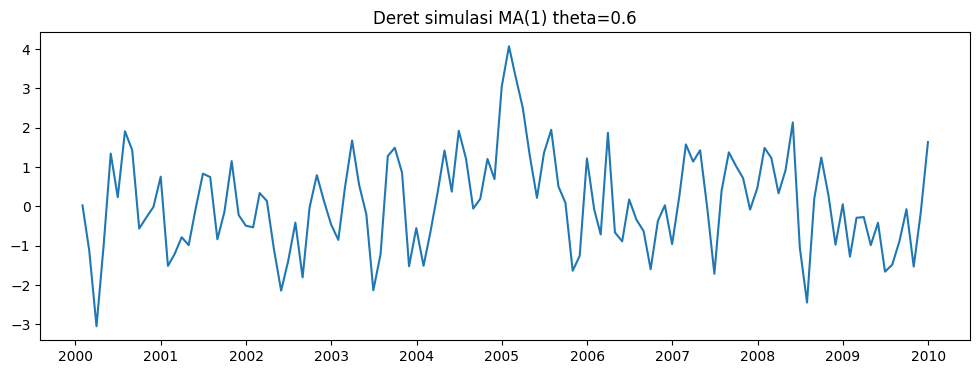

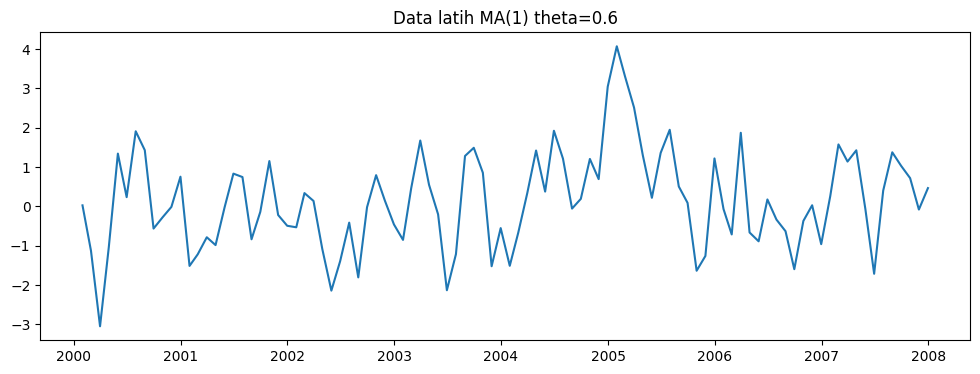

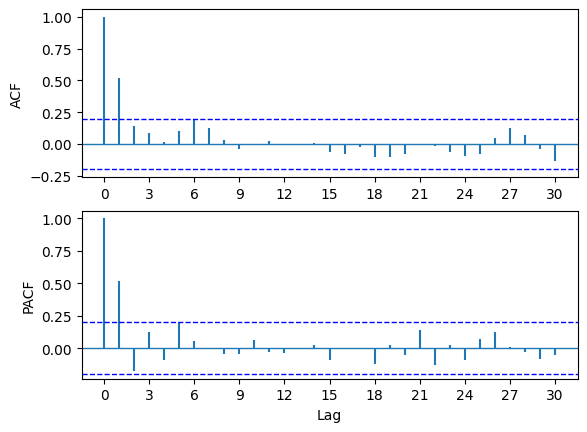


--- EACF (jika R tersedia) ---
AR/MA
  0 1 2 3 4 5 6 7 8 9 10 11 12 13
0 x o o o o o o o o o o  o  o  o 
1 x x o o o o o o o o o  o  o  o 
2 x o o o o o o o o o o  o  o  o 
3 x o o x o o o o o o o  o  o  o 
4 x x o x o o o o o o o  o  o  o 
5 x o o o o o o o o o o  o  o  o 
6 x o o o o o o o o o o  o  o  o 
7 x o o o o x o o o o o  o  o  o 
ARIMA(0, 0, 1): AIC=284.644, BIC=292.337
ARIMA(1, 0, 0): AIC=289.839, BIC=297.532
ARIMA(1, 0, 1): AIC=286.108, BIC=296.365
ARIMA(2, 0, 0): AIC=288.829, BIC=299.087

Model terbaik berdasarkan AIC: ARIMA(0, 0, 1)
                               SARIMAX Results                                
Dep. Variable:                    MA1   No. Observations:                   96
Model:                 ARIMA(0, 0, 1)   Log Likelihood                -139.322
Date:                Wed, 23 Sep 2026   AIC                            284.644
Time:                        01:23:26   BIC                            292.337
Sample:                    01-31-2000   HQIC      

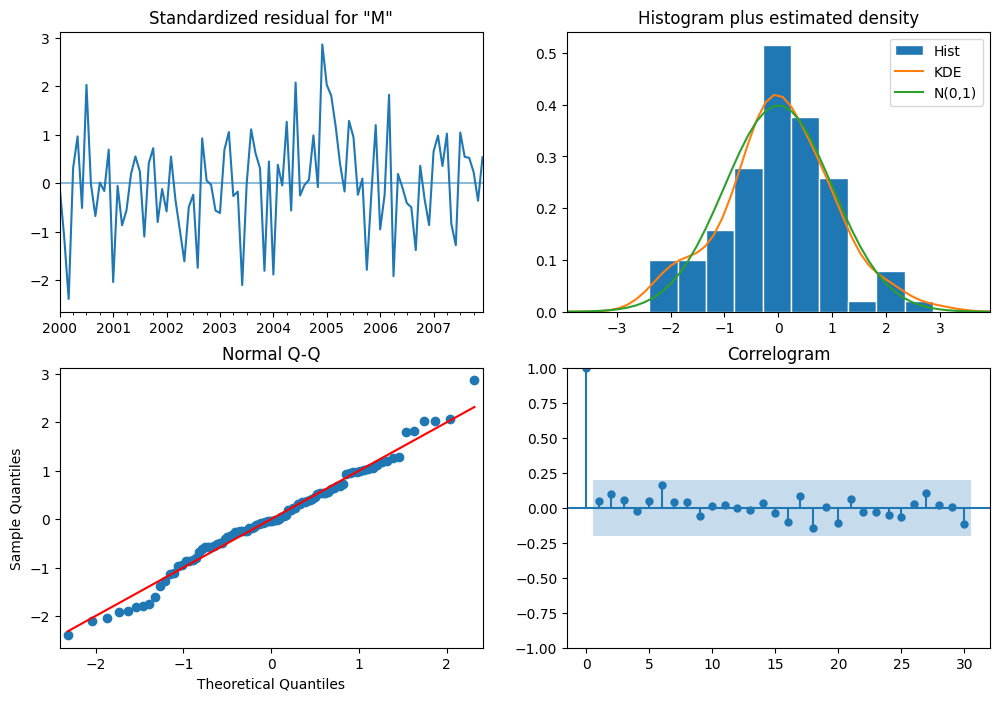


--- Diagnostik Sisaan ---
Ljung-Box p-value (lag 10): 0.8751259676985352
ARCH p-value (lag 10): 0.28448503073121145
Runs test p-value: 0.806728075242825
Shapiro-Wilk p-value: 0.4487261255644476

Perbandingan AIC/BIC:
                  AIC         BIC
(0, 0, 1)  284.643904  292.336949
(1, 0, 0)  289.838924  297.531969
(1, 0, 1)  286.107847  296.365240
(2, 0, 0)  288.829294  299.086687


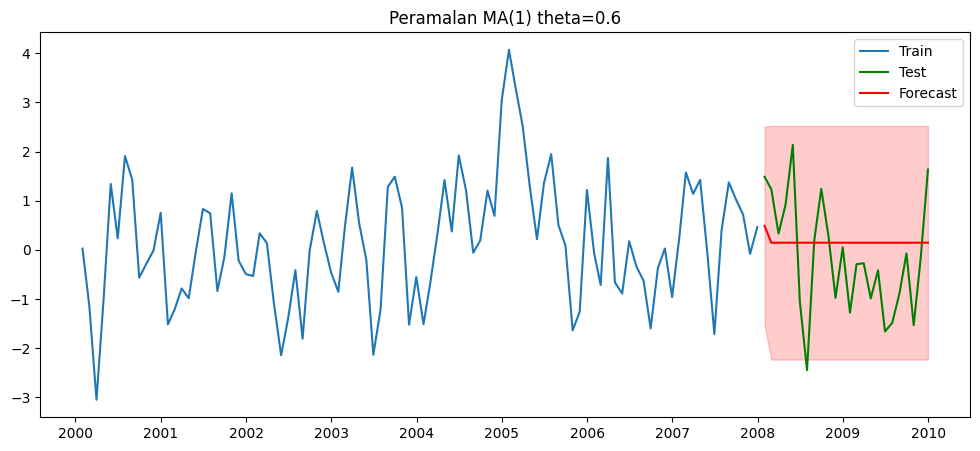

MA(1) theta=0.6 - Train: MAPE=199.691%, RMSE=1.0322, MAE=0.7885
MA(1) theta=0.6 - Test: MAPE=114.791%, RMSE=1.1823, MAE=0.9768

############################################################
SIMULASI AR(2) dengan phi1=0.9, phi2=-0.5, n=100
############################################################

ANALISIS AR(2) phi1=0.9 phi2=-0.5
n train = 80, n test = 20


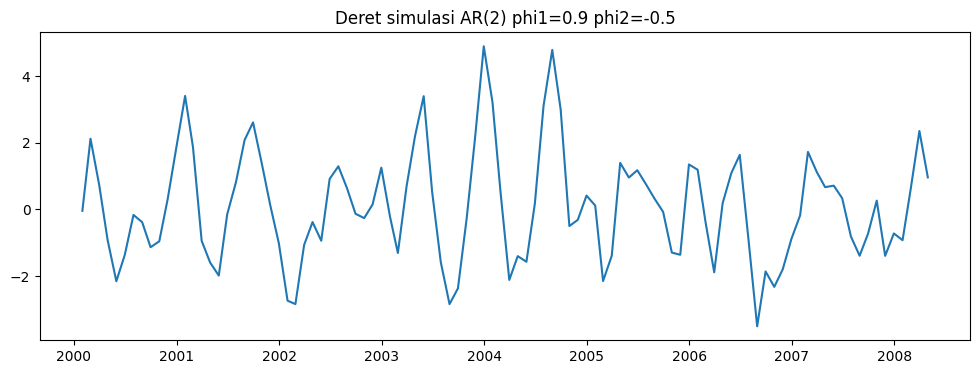

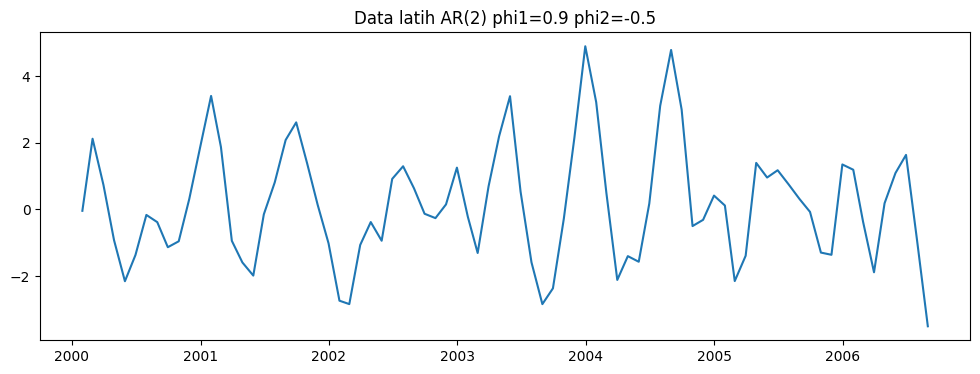

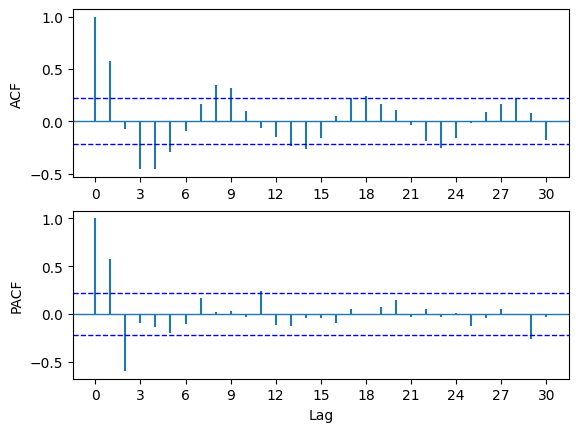


--- EACF (jika R tersedia) ---
AR/MA
  0 1 2 3 4 5 6 7 8 9 10 11 12 13
0 x o x x x o o x x o o  o  o  x 
1 x o x x x o o x x o o  o  o  o 
2 o o x o o o o o x o o  o  o  o 
3 x o x o o o o o o o o  o  o  o 
4 x o o o o o o o o o o  o  o  o 
5 o x o o o o o o o o o  o  o  o 
6 o x o x o o o o o x o  o  o  o 
7 o x o o o o o o o x o  o  o  o 
ARIMA(2, 0, 0): AIC=244.565, BIC=254.093
ARIMA(1, 0, 0): AIC=287.563, BIC=294.709
ARIMA(0, 0, 1): AIC=269.556, BIC=276.702
ARIMA(1, 0, 1): AIC=264.451, BIC=273.979

Model terbaik berdasarkan AIC: ARIMA(2, 0, 0)
                               SARIMAX Results                                
Dep. Variable:                    AR2   No. Observations:                   80
Model:                 ARIMA(2, 0, 0)   Log Likelihood                -118.282
Date:                Wed, 23 Sep 2026   AIC                            244.565
Time:                        01:23:29   BIC                            254.093
Sample:                    01-31-2000   HQIC      

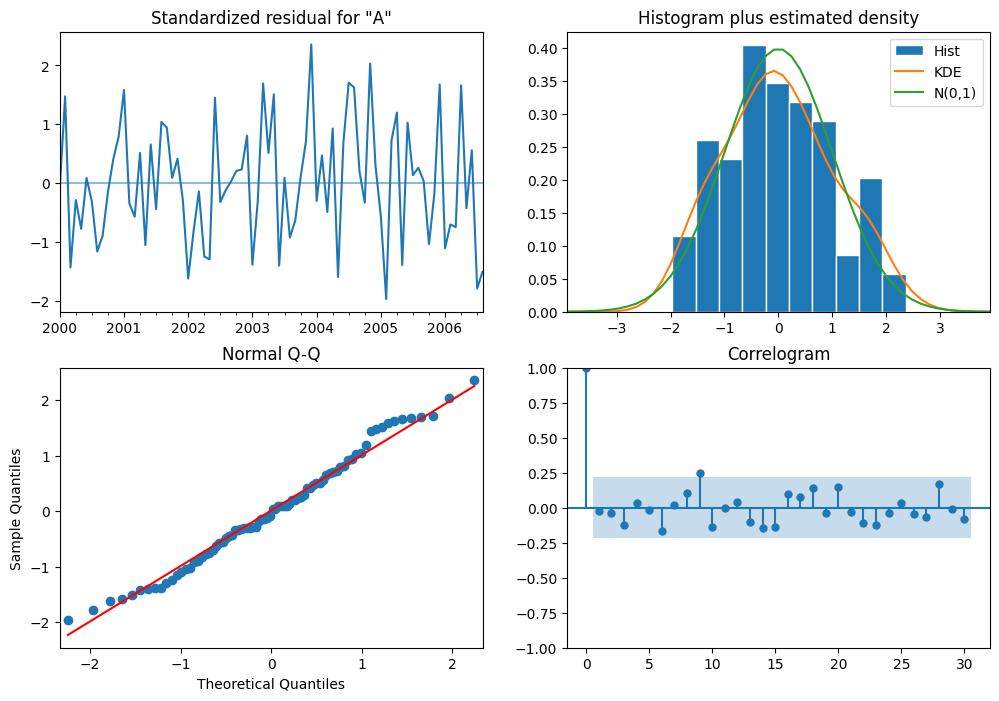


--- Diagnostik Sisaan ---
Ljung-Box p-value (lag 10): 0.26180238872523154
ARCH p-value (lag 10): 0.6443265775539082
Runs test p-value: 1.0
Shapiro-Wilk p-value: 0.2977937500860204

Perbandingan AIC/BIC:
                  AIC         BIC
(2, 0, 0)  244.564845  254.092952
(1, 0, 0)  287.562869  294.708948
(0, 0, 1)  269.555987  276.702066
(1, 0, 1)  264.450541  273.978647


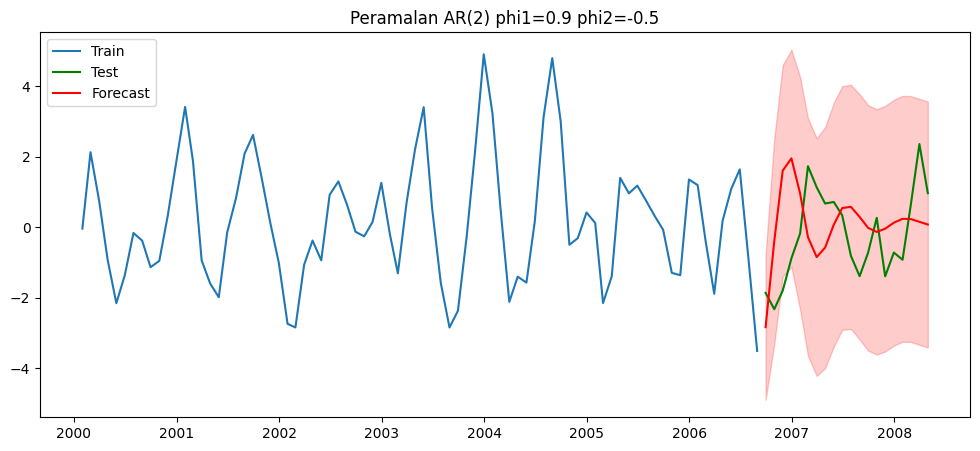

AR(2) phi1=0.9 phi2=-0.5 - Train: MAPE=125.156%, RMSE=1.0625, MAE=0.8629
AR(2) phi1=0.9 phi2=-0.5 - Test: MAPE=151.500%, RMSE=1.5914, MAE=1.3688

############################################################
SIMULASI ARMA(1,1) dengan phi=0.4, theta=0.6, n=200
############################################################

ANALISIS ARMA(1,1) phi=0.4 theta=0.6
n train = 160, n test = 40


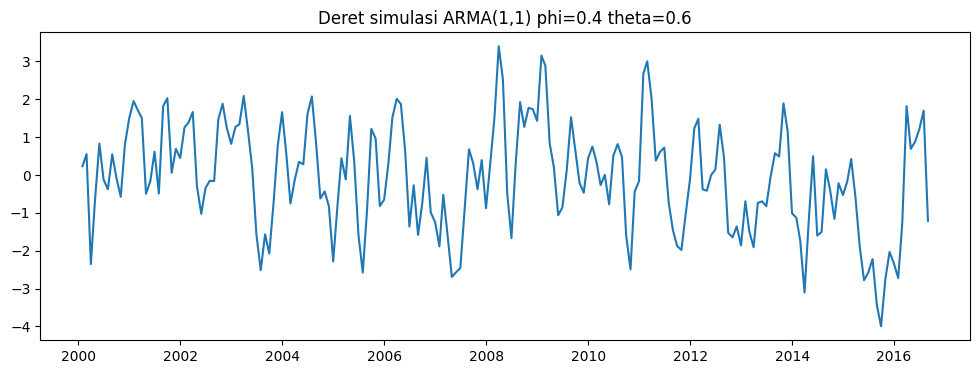

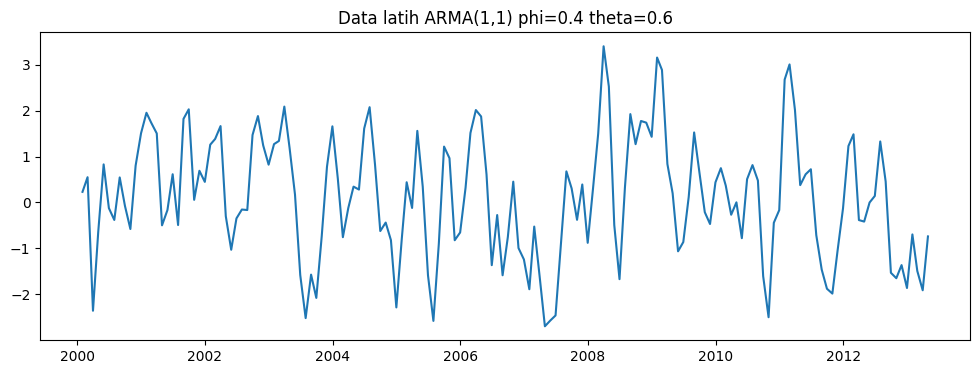

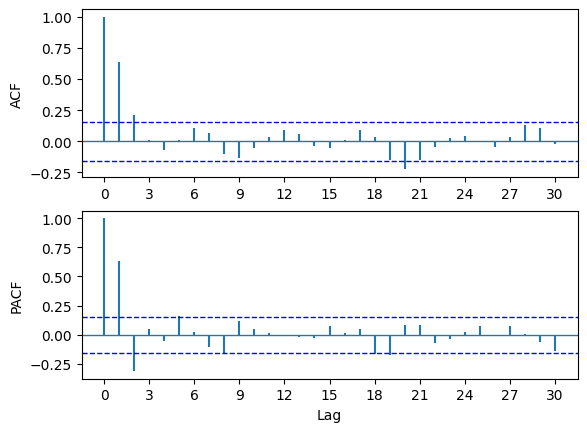


--- EACF (jika R tersedia) ---
AR/MA
  0 1 2 3 4 5 6 7 8 9 10 11 12 13
0 x x o o o o o o o o o  o  o  o 
1 x x o o o x o o o o o  o  o  o 
2 o x o o o o o o o o o  o  o  o 
3 x o x o o o o o o o o  o  o  o 
4 x x x o o o o o o o o  o  o  o 
5 o x x o o o o o o o o  o  o  o 
6 o x x o o o o o o o o  o  o  o 
7 x x x x x x o o o o o  o  o  o 
ARIMA(1, 0, 1): AIC=451.272, BIC=463.573
ARIMA(0, 0, 1): AIC=459.203, BIC=468.429
ARIMA(1, 0, 0): AIC=466.525, BIC=475.751
ARIMA(2, 0, 0): AIC=452.326, BIC=464.627

Model terbaik berdasarkan AIC: ARIMA(1, 0, 1)
                               SARIMAX Results                                
Dep. Variable:                 ARMA11   No. Observations:                  160
Model:                 ARIMA(1, 0, 1)   Log Likelihood                -221.636
Date:                Wed, 23 Sep 2026   AIC                            451.272
Time:                        01:23:31   BIC                            463.573
Sample:                    01-31-2000   HQIC      

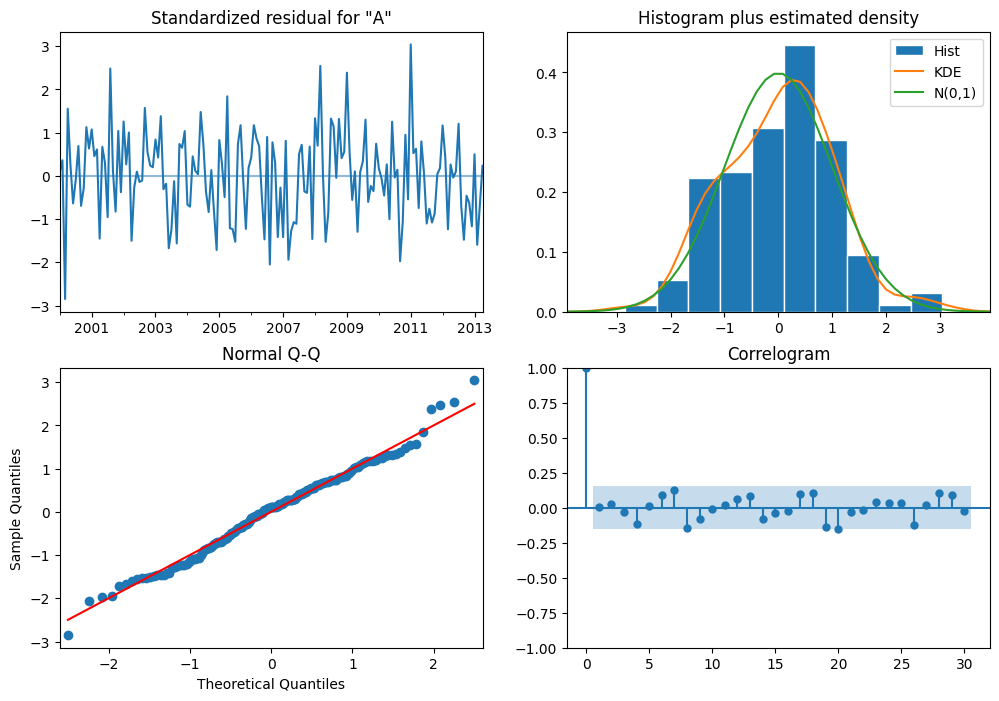


--- Diagnostik Sisaan ---
Ljung-Box p-value (lag 10): 0.3448294611321105
ARCH p-value (lag 10): 0.7306486956423064
Runs test p-value: 0.5712012338441511
Shapiro-Wilk p-value: 0.33433597178408303

Perbandingan AIC/BIC:
                  AIC         BIC
(1, 0, 1)  451.272262  463.572957
(0, 0, 1)  459.203325  468.428846
(1, 0, 0)  466.525046  475.750567
(2, 0, 0)  452.326285  464.626980


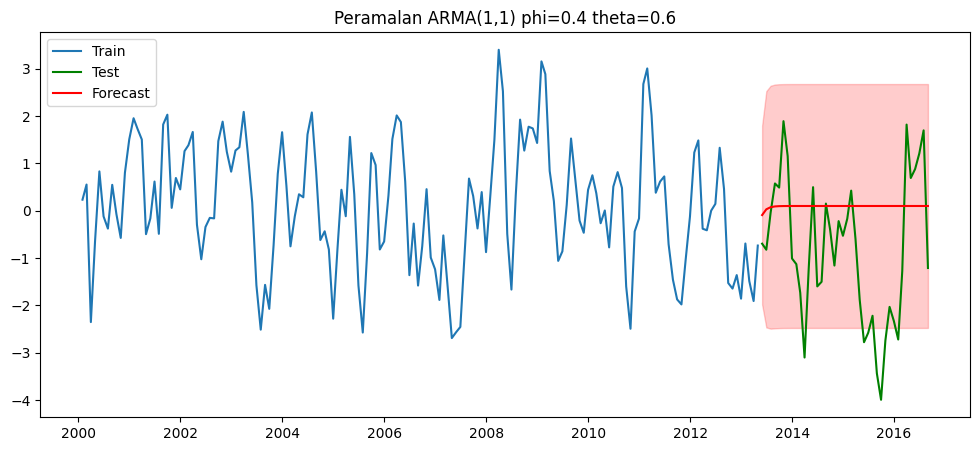

ARMA(1,1) phi=0.4 theta=0.6 - Train: MAPE=1110.253%, RMSE=0.9653, MAE=0.7746
ARMA(1,1) phi=0.4 theta=0.6 - Test: MAPE=106.144%, RMSE=1.7629, MAE=1.4479

Analisis selesai.


In [67]:
# =========================================================
# ANALISIS DERET WAKTU STASIONER - SIMULASI MA(1), AR(2), ARMA(1,1)
# =========================================================

# ---------- INSTALASI DEPENDENSI (jalankan sekali) ----------
# !pip install PythonTsa rpy2 statsmodels scikit-learn scipy matplotlib pandas numpy -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import het_arch, acorr_ljungbox
from statsmodels.sandbox.stats.runs import runstest_1samp
from scipy.stats import shapiro, jarque_bera
from sklearn.metrics import mean_squared_error, mean_absolute_error
from PythonTsa.plot_acf_pacf import acf_pacf_fig
import warnings
warnings.filterwarnings("ignore")

# =========================================================
# GANTI SEED INI DENGAN JUMLAH 2 DIGIT TERAKHIR NIM KELOMPOK
# =========================================================
seed = 33 + 37 + 50   # <-- GANTI DENGAN NIM KELOMPOK
rng = np.random.default_rng(seed)
print("Seed yang digunakan =", seed)

# ---------- FUNGSI BANTU ----------
def mape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mask = np.abs(y_true) > 1e-10
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def eval_metrik(y_true, y_pred, label):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape_val = mape(y_true, y_pred)
    print(f"{label}: MAPE={mape_val:.3f}%, RMSE={rmse:.4f}, MAE={mae:.4f}")
    return mape_val, rmse, mae

def simulasi_ma1(n=120, theta=0.6, rng=None, burn=200):
    if rng is None:
        rng = np.random.default_rng()
    e = rng.normal(size=n + burn)
    y = np.zeros(n + burn)
    for t in range(1, n + burn):
        y[t] = e[t] + theta * e[t-1]
    idx = pd.date_range("2000-01-01", periods=n, freq="M")
    return pd.Series(y[burn:], index=idx, name="MA1")

def simulasi_ar2(n=100, phi1=0.9, phi2=-0.5, rng=None, burn=200):
    if rng is None:
        rng = np.random.default_rng()
    e = rng.normal(size=n + burn)
    y = np.zeros(n + burn)
    for t in range(2, n + burn):
        y[t] = phi1 * y[t-1] + phi2 * y[t-2] + e[t]
    idx = pd.date_range("2000-01-01", periods=n, freq="M")
    return pd.Series(y[burn:], index=idx, name="AR2")

def simulasi_arma11(n=200, phi=0.4, theta=0.6, rng=None, burn=200):
    if rng is None:
        rng = np.random.default_rng()
    e = rng.normal(size=n + burn)
    y = np.zeros(n + burn)
    for t in range(1, n + burn):
        y[t] = phi * y[t-1] + e[t] + theta * e[t-1]
    idx = pd.date_range("2000-01-01", periods=n, freq="M")
    return pd.Series(y[burn:], index=idx, name="ARMA11")

def split_train_test(y, frac=0.8):
    n = len(y)
    ntrain = int(np.floor(n * frac))
    return y.iloc[:ntrain], y.iloc[ntrain:]

def plot_eacf_r(series, var_name="data"):
    """Plot EACF menggunakan R (rpy2). Jika R tidak tersedia, lewati."""
    try:
        import rpy2.robjects as robjects
        from rpy2.robjects import numpy2ri
        from rpy2.robjects.packages import importr
        numpy2ri.activate()
        # Muat paket TSA
        try:
            tsa = importr('TSA')
        except Exception:
            utils = importr('utils')
            utils.install_packages('TSA', repos='https://cran.rstudio.com/')
            tsa = importr('TSA')
        # Konversi pandas Series ke array R
        r_vec = robjects.FloatVector(series.values)
        robjects.globalenv[var_name] = r_vec
        robjects.r(f'eacf(as.numeric({var_name}))')
        numpy2ri.deactivate()
    except ImportError:
        print("rpy2 tidak terpasang, EACF dilewati.")
    except Exception as e:
        print(f"Gagal menjalankan EACF via R: {e}")

def analisis_ts(y, nama, train_frac=0.8,
                candidates=[(0,0,1), (1,0,0), (1,0,1), (2,0,0)]):
    train, test = split_train_test(y, train_frac)
    print(f"\n{'='*50}")
    print(f"ANALISIS {nama}")
    print(f"{'='*50}")
    print(f"n train = {len(train)}, n test = {len(test)}")

    # Plot deret simulasi
    plt.figure(figsize=(12, 4))
    plt.plot(y)
    plt.title(f"Deret simulasi {nama}")
    plt.show()

    # Plot data latih
    plt.figure(figsize=(12, 4))
    plt.plot(train)
    plt.title(f"Data latih {nama}")
    plt.show()

    # ACF dan PACF data latih
    acf_pacf_fig(train, both=True, lag=30)
    plt.show()

    # EACF (via R)
    print("\n--- EACF (jika R tersedia) ---")
    plot_eacf_r(train, var_name="train_data")

    # Pengepasan beberapa model kandidat
    models = {}
    for order in candidates:
        try:
            m = ARIMA(train, order=order).fit()
            models[str(order)] = m
            print(f"ARIMA{order}: AIC={m.aic:.3f}, BIC={m.bic:.3f}")
        except Exception as e:
            print(f"ARIMA{order} gagal: {e}")

    if not models:
        print("Tidak ada model yang berhasil dipasang.")
        return None, None, None, train, test

    # Model terbaik berdasarkan AIC
    best_key = min(models, key=lambda k: models[k].aic)
    best = models[best_key]
    print(f"\nModel terbaik berdasarkan AIC: ARIMA{best_key}")
    print(best.summary())

    # Diagnostik sisaan
    best.plot_diagnostics(figsize=(12, 8), lags=30)
    plt.show()

    print("\n--- Diagnostik Sisaan ---")
    print("Ljung-Box p-value (lag 10):",
          acorr_ljungbox(best.resid, lags=[10], return_df=True)["lb_pvalue"].values[0])
    print("ARCH p-value (lag 10):", het_arch(best.resid, nlags=10)[1])
    print("Runs test p-value:", runstest_1samp(best.resid, correction=False)[1])
    print("Shapiro-Wilk p-value:", shapiro(best.resid)[1])

    # Perbandingan AIC/BIC
    print("\nPerbandingan AIC/BIC:")
    print(pd.DataFrame({
        k: {"AIC": v.aic, "BIC": v.bic} for k, v in models.items()
    }).T)

    # Peramalan data uji
    fc = best.get_forecast(len(test)).summary_frame(alpha=0.05)

    plt.figure(figsize=(12, 5))
    plt.plot(train.index, train, label="Train")
    plt.plot(test.index, test, label="Test", color="green")
    plt.plot(fc.index, fc["mean"], label="Forecast", color="red")
    plt.fill_between(fc.index,
                     fc["mean_ci_lower"],
                     fc["mean_ci_upper"],
                     color="red", alpha=0.2)
    plt.legend()
    plt.title(f"Peramalan {nama}")
    plt.show()

    # Evaluasi
    train_pred = best.fittedvalues
    eval_metrik(train, train_pred, f"{nama} - Train")
    eval_metrik(test, fc["mean"], f"{nama} - Test")

    return best, models, fc, train, test

# =========================================================
# 1. SIMULASI DAN ANALISIS MA(1)
# =========================================================
print("\n" + "#"*60)
print("SIMULASI MA(1) dengan theta = 0.6, n = 120")
print("#"*60)

y_ma1 = simulasi_ma1(n=120, theta=0.6, rng=rng)
best_ma1, models_ma1, fc_ma1, train_ma1, test_ma1 = analisis_ts(
    y_ma1,
    "MA(1) theta=0.6",
    train_frac=0.8,
    candidates=[(0,0,1), (1,0,0), (1,0,1), (2,0,0)]
)

# =========================================================
# 2. SIMULASI DAN ANALISIS AR(2)
# =========================================================
print("\n" + "#"*60)
print("SIMULASI AR(2) dengan phi1=0.9, phi2=-0.5, n=100")
print("#"*60)

y_ar2 = simulasi_ar2(n=100, phi1=0.9, phi2=-0.5, rng=rng)
best_ar2, models_ar2, fc_ar2, train_ar2, test_ar2 = analisis_ts(
    y_ar2,
    "AR(2) phi1=0.9 phi2=-0.5",
    train_frac=0.8,
    candidates=[(2,0,0), (1,0,0), (0,0,1), (1,0,1)]
)

# =========================================================
# 3. SIMULASI DAN ANALISIS ARMA(1,1)
# =========================================================
print("\n" + "#"*60)
print("SIMULASI ARMA(1,1) dengan phi=0.4, theta=0.6, n=200")
print("#"*60)

y_arma = simulasi_arma11(n=200, phi=0.4, theta=0.6, rng=rng)
best_arma, models_arma, fc_arma, train_arma, test_arma = analisis_ts(
    y_arma,
    "ARMA(1,1) phi=0.4 theta=0.6",
    train_frac=0.8,
    candidates=[(1,0,1), (0,0,1), (1,0,0), (2,0,0)]
)

print("\nAnalisis selesai.")